# imports

In [1]:
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim")
sys.path.insert(0, os.getcwd())

In [2]:
import astropy.units as u
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import lifesim
from spectres import spectres

from lifesim.util.radiation import black_body

In [3]:
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# import spectrum

In [6]:
data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/thermal_noise_testing/Earth_PRTunits_10pc.txt',header=None, sep='\s+')

lam_PRT=data[0].values*u.micron
f_PRT=data[1].values*u.erg/u.cm**2/u.s/u.Hz
f_lifesim = f_PRT.to(u.photon / u.m**2 / u.s / u.micron,\
                      equivalencies=u.spectral_density(lam_PRT))

#f_lifesim = f_lifesim.to(u.photon / u.s / u.meter**3)
lam_lifesim = lam_PRT.to(u.micron)
f_lifesim *= np.diff(lam_lifesim.value, append=[0]) * u.micron
lam_lifesim = lam_lifesim.to(u.meter)


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4777/58824230.py:1: SyntaxWarning: invalid escape sequence '\s'
  data=pd.read_csv('/home/kirschkobold/documents/life_internship/LIFEsim_yields/thermal_noise_testing/Earth_PRTunits_10pc.txt',header=None, sep='\s+')


In [7]:
bb = black_body(mode='planet',
                bins=lam_lifesim.value,
                width=np.diff(lam_lifesim.value, append=[0]),
                temp=288,
                radius=1,
                distance=10.)

In [8]:
# remove last element from arrays
f_lifesim = f_lifesim[:-1]
lam_lifesim = lam_lifesim[:-1]
bb = bb[:-1]

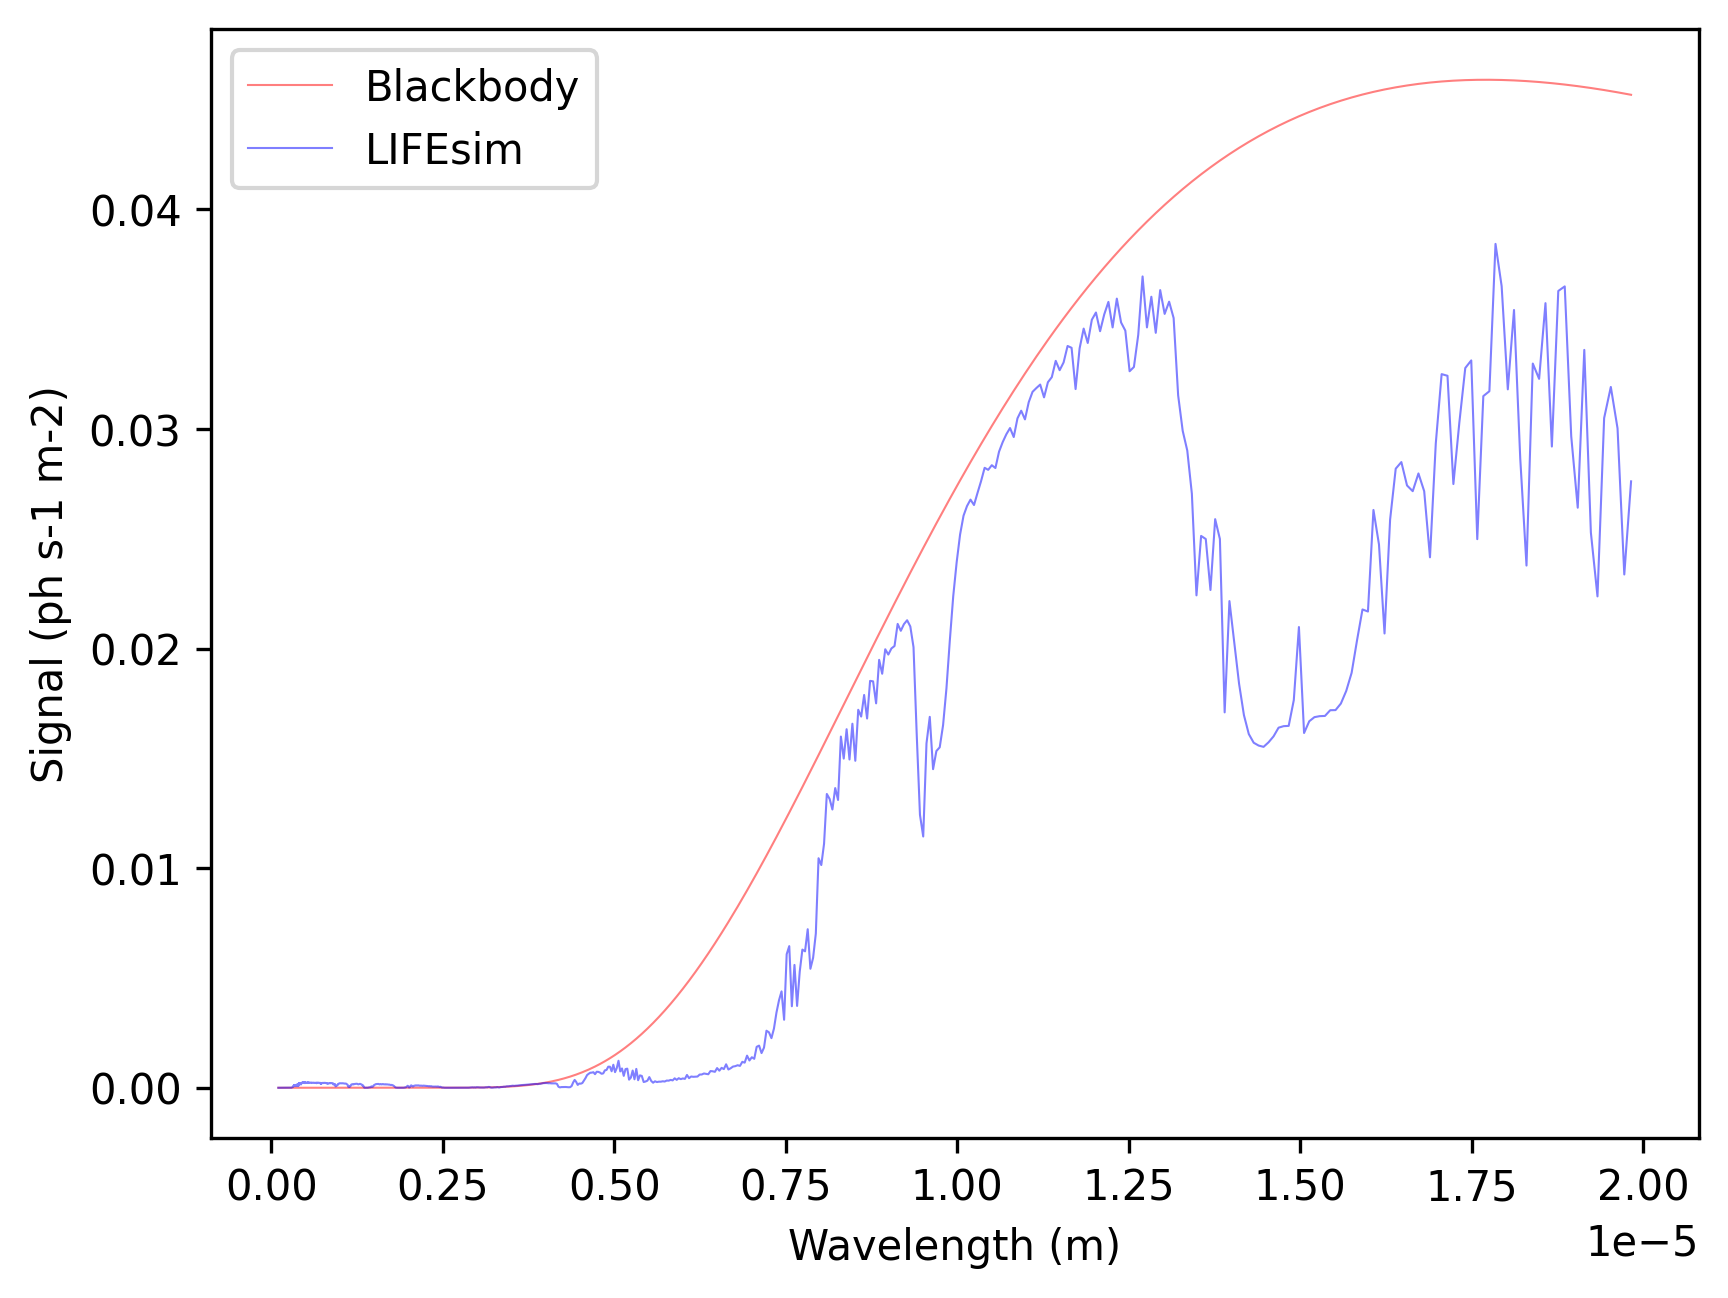

In [9]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim.value, bb, lw=0.5, c='red', alpha=0.5, label='Blackbody')
ln2 = plt.plot(lam_lifesim.value, f_lifesim, lw=0.5, c='blue', alpha=0.5, label='LIFEsim')

lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

#ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-2)')
plt.show()

# LIFEsim setup

In [10]:
bus = lifesim.Bus()

bus.data.options.set_scenario('baseline')

In [11]:
instrument = lifesim.Instrument(name='inst')
bus.add_module(instrument)

transm = lifesim.TransmissionMap(name='transm')
bus.add_module(transm)

exo = lifesim.PhotonNoiseExozodi(name='exo')
bus.add_module(exo)
local = lifesim.PhotonNoiseLocalzodi(name='local')
bus.add_module(local)
star = lifesim.PhotonNoiseStar(name='star')
bus.add_module(star)
mirror = lifesim.PhotonNoiseThermal(name='mirror')
bus.add_module(mirror)
darkcurrent = lifesim.ElectronNoiseDarkCurrent(name='darkcurrent')
bus.add_module(darkcurrent)


# connect all modules
bus.connect(('inst', 'transm'))
bus.connect(('inst', 'exo'))
bus.connect(('inst', 'local'))
bus.connect(('inst', 'star'))
bus.connect(('inst', 'mirror'))
bus.connect(('inst', 'darkcurrent'))


bus.connect(('star', 'transm'))

instrument.apply_options()

In [12]:
integration_time = 55*60*60

prefactor = (integration_time 
             * bus.data.inst['eff_tot'] 
             * bus.data.inst['telescope_area'] 
             * bus.data.inst['wl_bin_widths'])

# run spectrum through LIFEsim

In [13]:
spectrum, flux_planet, noise = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_4777/2342845030.py:3: SyntaxWarning: invalid escape sequence '\c'
  ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')


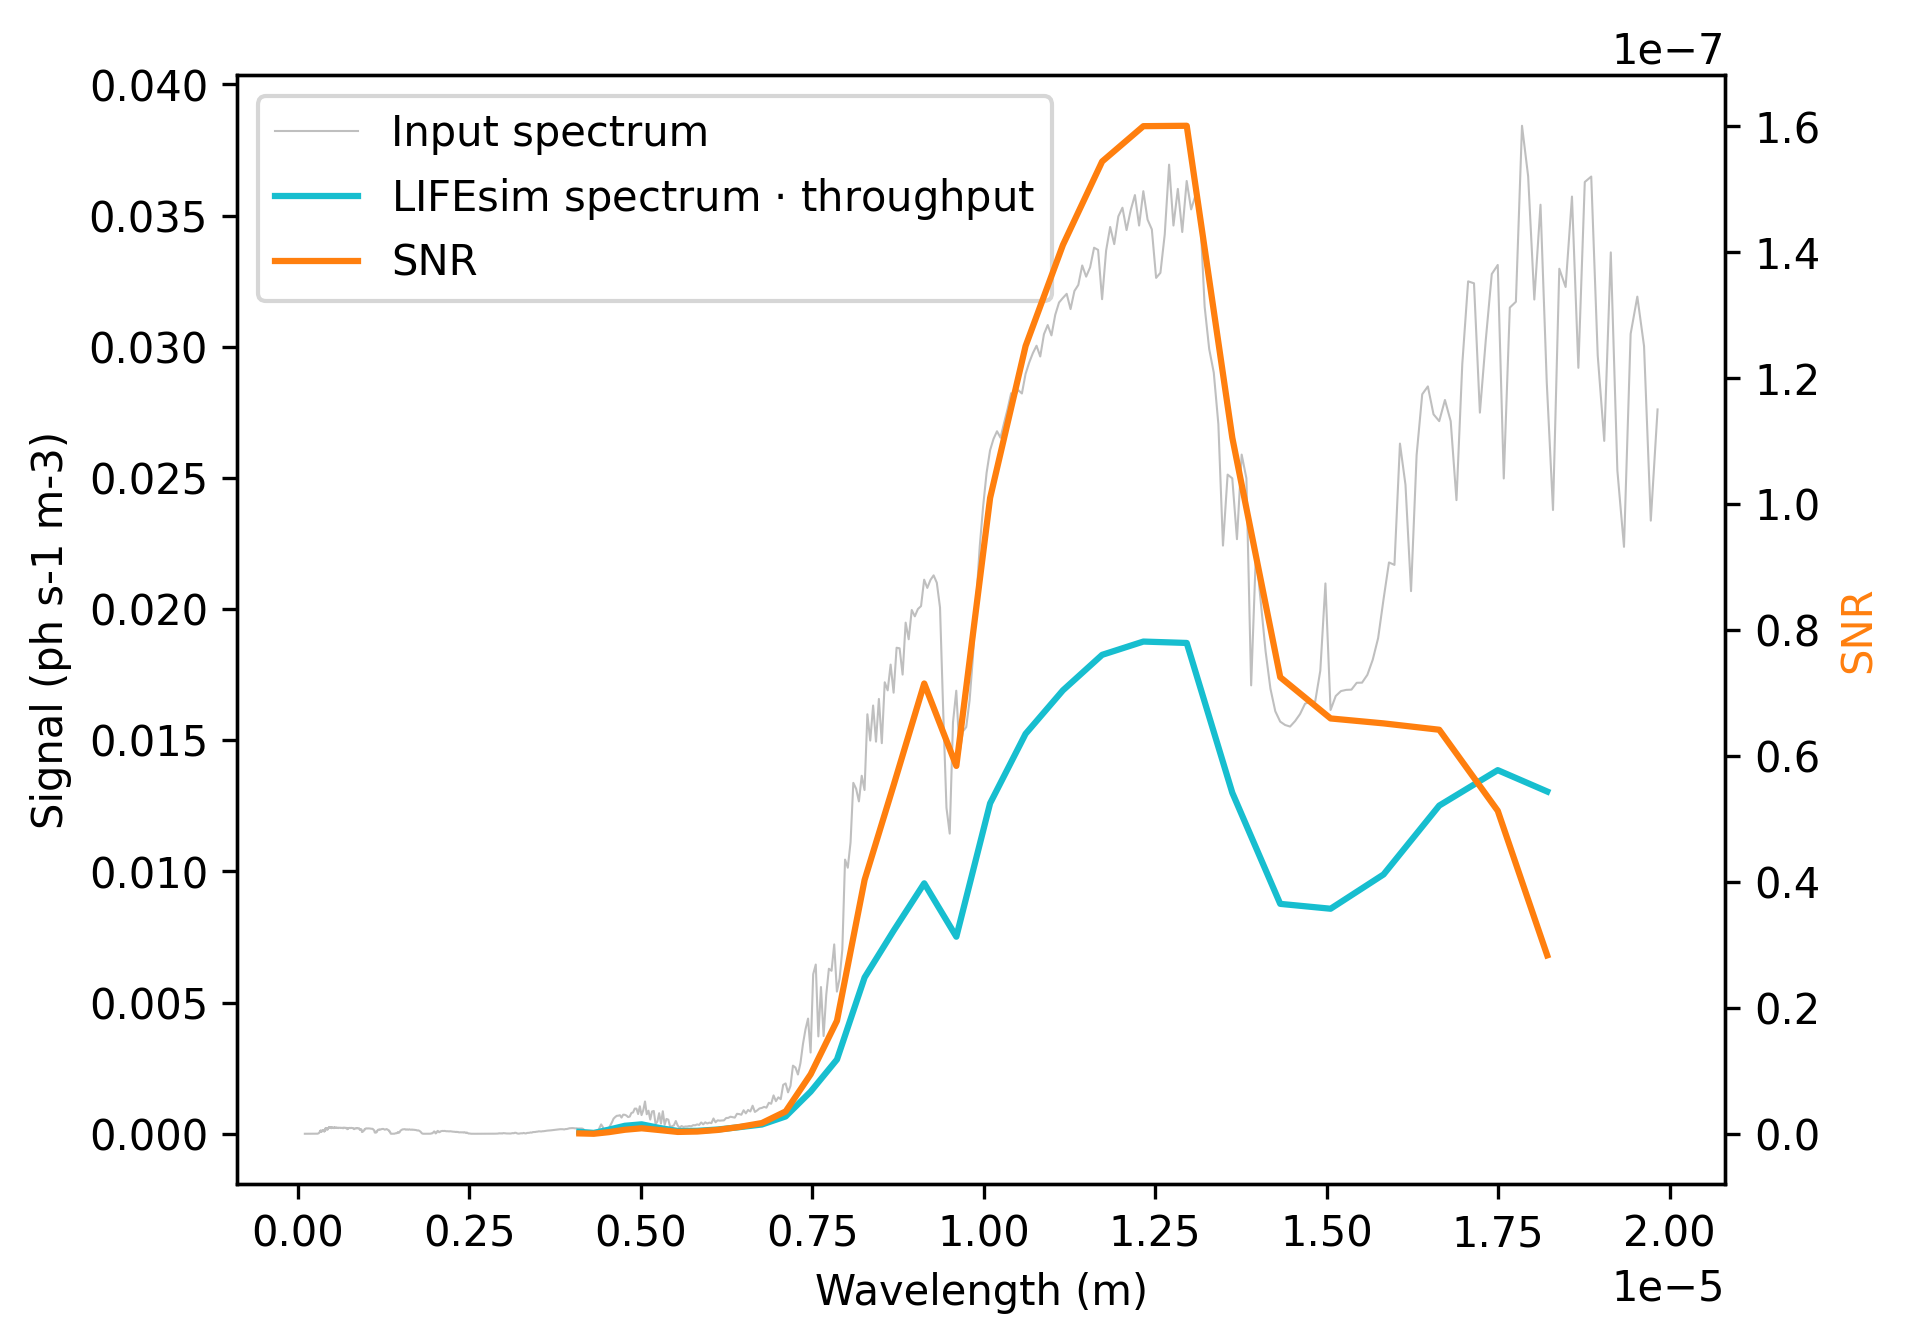

In [14]:
fig, ax = plt.subplots(dpi=300)
ln1 = plt.plot(lam_lifesim, f_lifesim, lw=0.5, c='gray', alpha=0.5, label='Input spectrum')
ln2 = plt.plot(spectrum[0], flux_planet / prefactor, c='tab:cyan', label='LIFEsim spectrum $\cdot$ throughput')
ax2=ax.twinx()
ln3 = ax2.plot(spectrum[0], spectrum[1],c='tab:orange', label='SNR')

lns = ln1 + ln2 + ln3
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)

ax.set_xlabel('Wavelength (m)')
ax.set_ylabel('Signal (ph s-1 m-3)')
ax2.set_ylabel("SNR",c='tab:orange')
plt.show()

# safe mode off

In [15]:
# test safe mode off
spectrum_tmo, flux_planet_tmo, noise_tmo = instrument.get_spectrum(temp_s=5778,  # star temperature in K
                                                    radius_s=1,  # star radius in solar radii
                                                    distance_s=10,  # distance to system in pc
                                                    lat_s=0.78,  # ecliptic latitude of observation in rad
                                                    z=3,  # zodi level
                                                    angsep=0.1,  # angular separation of planet in arcsec
                                                    flux_planet_spectrum=[lam_lifesim, f_lifesim],
                                                    safe_mode=True,
                                                    integration_time=integration_time)

In [14]:
'''ArithmeticErrornoise_star = noise_tmo[1]
noise_star_local = noise_star[0]*bus.data.inst['wl_bins']
noise_star_starleak = noise_star[1]*bus.data.inst['wl_bins']

noise_universe = noise_tmo[2][0]*bus.data.inst['wl_bins']

noise_thermal = noise_tmo[3] 
noise_thermal_mirror = noise_thermal[0]*bus.data.inst['wl_bins']
noise_thermal_detector = noise_thermal[1]*bus.data.inst['wl_bins']

noise_dc_electron = noise_tmo[4][0]
noise_dc_photon = noise_dc_electron/0.7

noise_planet = noise_tmo[0]/integration_time - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon
'''

"ArithmeticErrornoise_star = noise_tmo[1]\nnoise_star_local = noise_star[0]*bus.data.inst['wl_bins']\nnoise_star_starleak = noise_star[1]*bus.data.inst['wl_bins']\n\nnoise_universe = noise_tmo[2][0]*bus.data.inst['wl_bins']\n\nnoise_thermal = noise_tmo[3] \nnoise_thermal_mirror = noise_thermal[0]*bus.data.inst['wl_bins']\nnoise_thermal_detector = noise_thermal[1]*bus.data.inst['wl_bins']\n\nnoise_dc_electron = noise_tmo[4][0]\nnoise_dc_photon = noise_dc_electron/0.7\n\nnoise_planet = noise_tmo[0]/integration_time - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon\n"

In [33]:
noise_star = noise_tmo[1]
noise_star_local = noise_star[0]
noise_star_starleak = noise_star[1]

noise_universe = noise_tmo[2][0]

noise_thermal = noise_tmo[3] 
noise_thermal_mirror = noise_thermal[0]
noise_thermal_detector = noise_thermal[2]
noise_thermal_inst = noise_thermal[1]

noise_dc_electron = noise_tmo[4][0]
noise_dc_photon = noise_dc_electron/0.7

noise_planet = noise_tmo[0]/integration_time/bus.data.inst['eff_tot']/bus.data.options.array['num_outputs'] - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon

In [34]:
x = spectrum_tmo[0] * 1e6

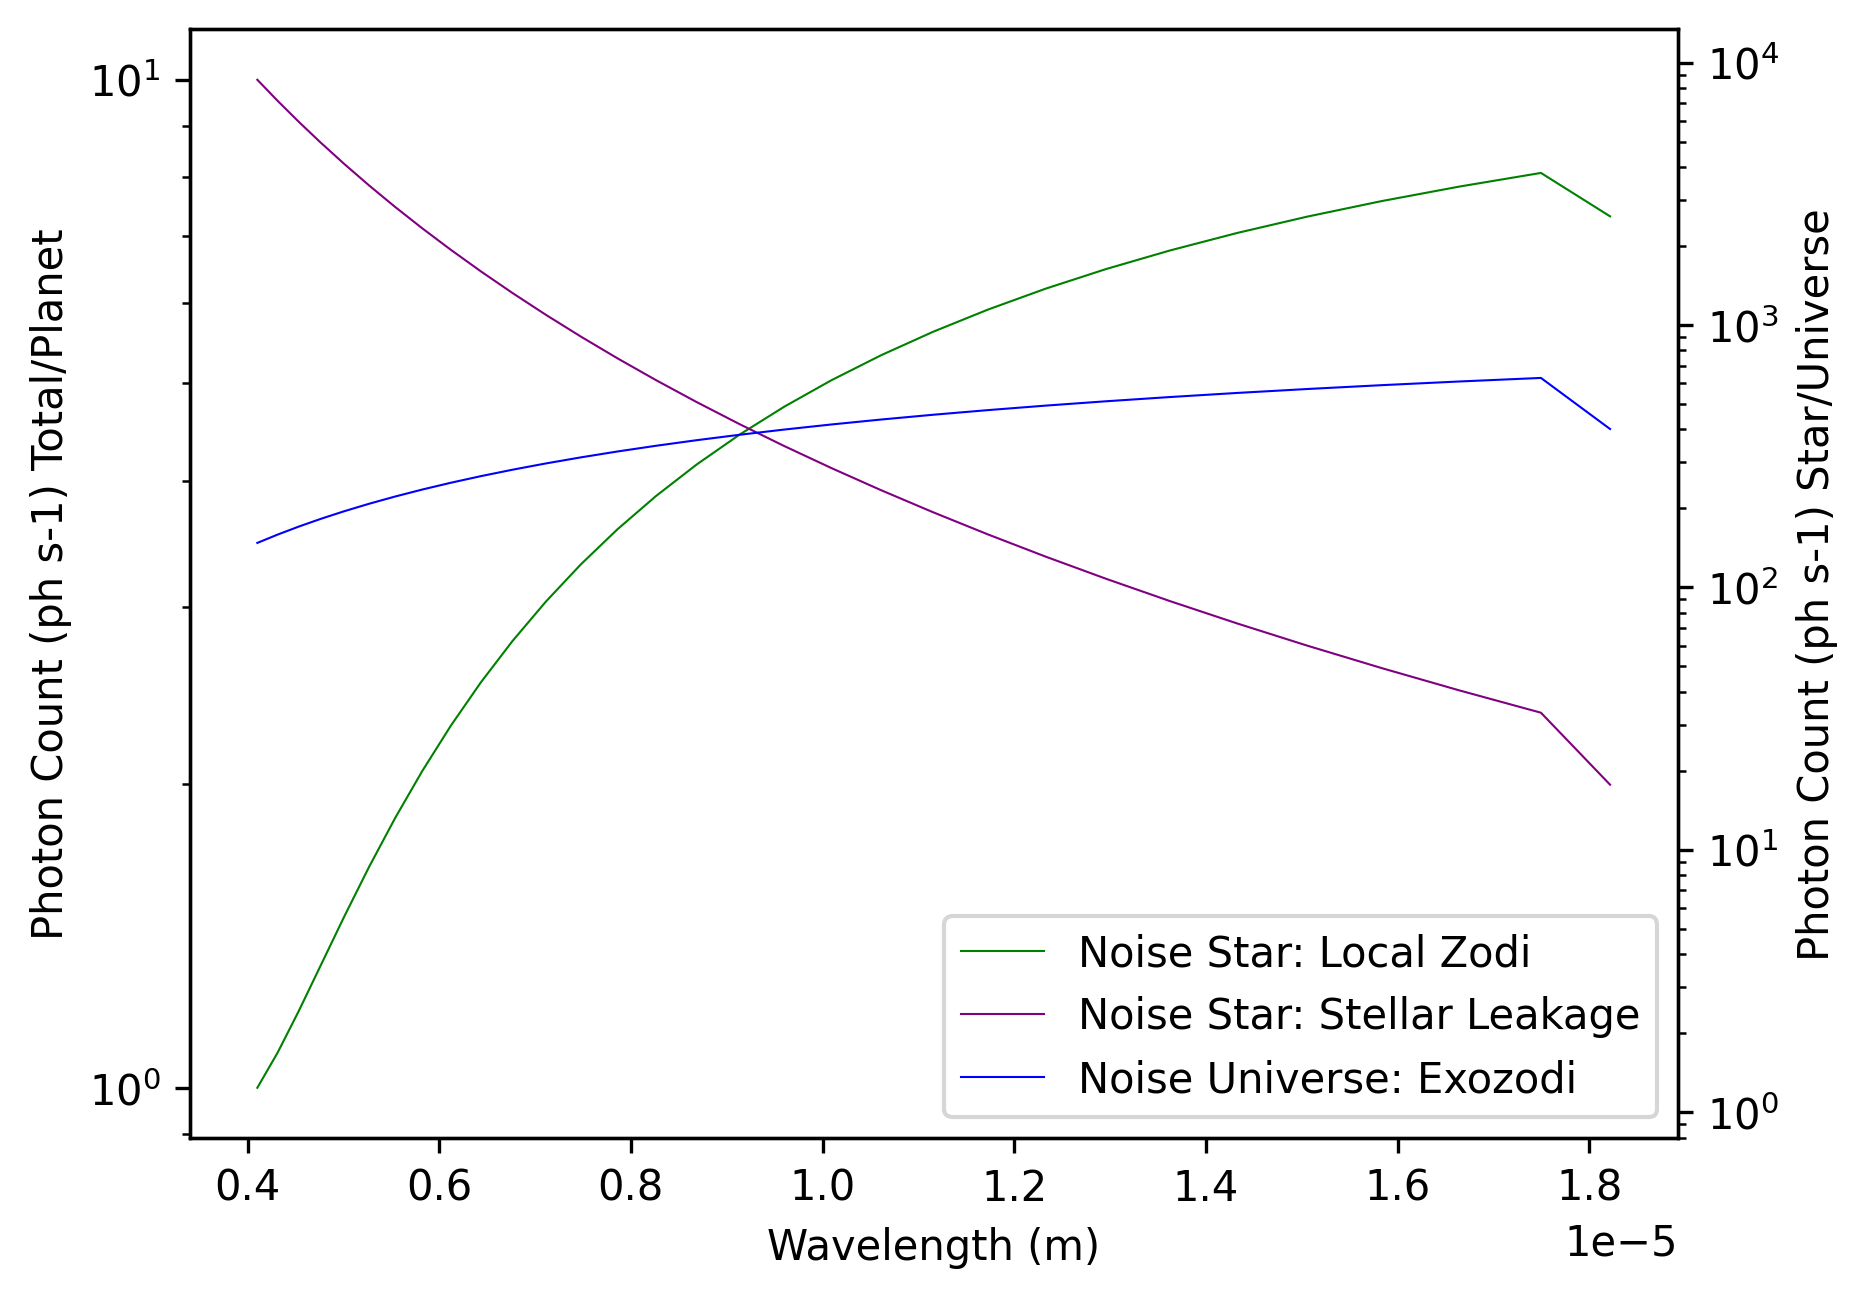

In [35]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')

ax2=ax.twinx()
ln1 = ax2.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')
ln2 = ax2.plot(spectrum_tmo[0], noise_star_starleak, lw=0.5, c='purple', label='Noise Star: Stellar Leakage')
ln3 = ax2.plot(spectrum_tmo[0], noise_universe, lw=0.5, c='blue', label='Noise Universe: Exozodi')

lns = ln1 + ln2 + ln3 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1) Total/Planet")
ax2.set_yscale('log')
ax2.set_ylabel('Photon Count (ph s-1) Star/Universe')

plt.show()

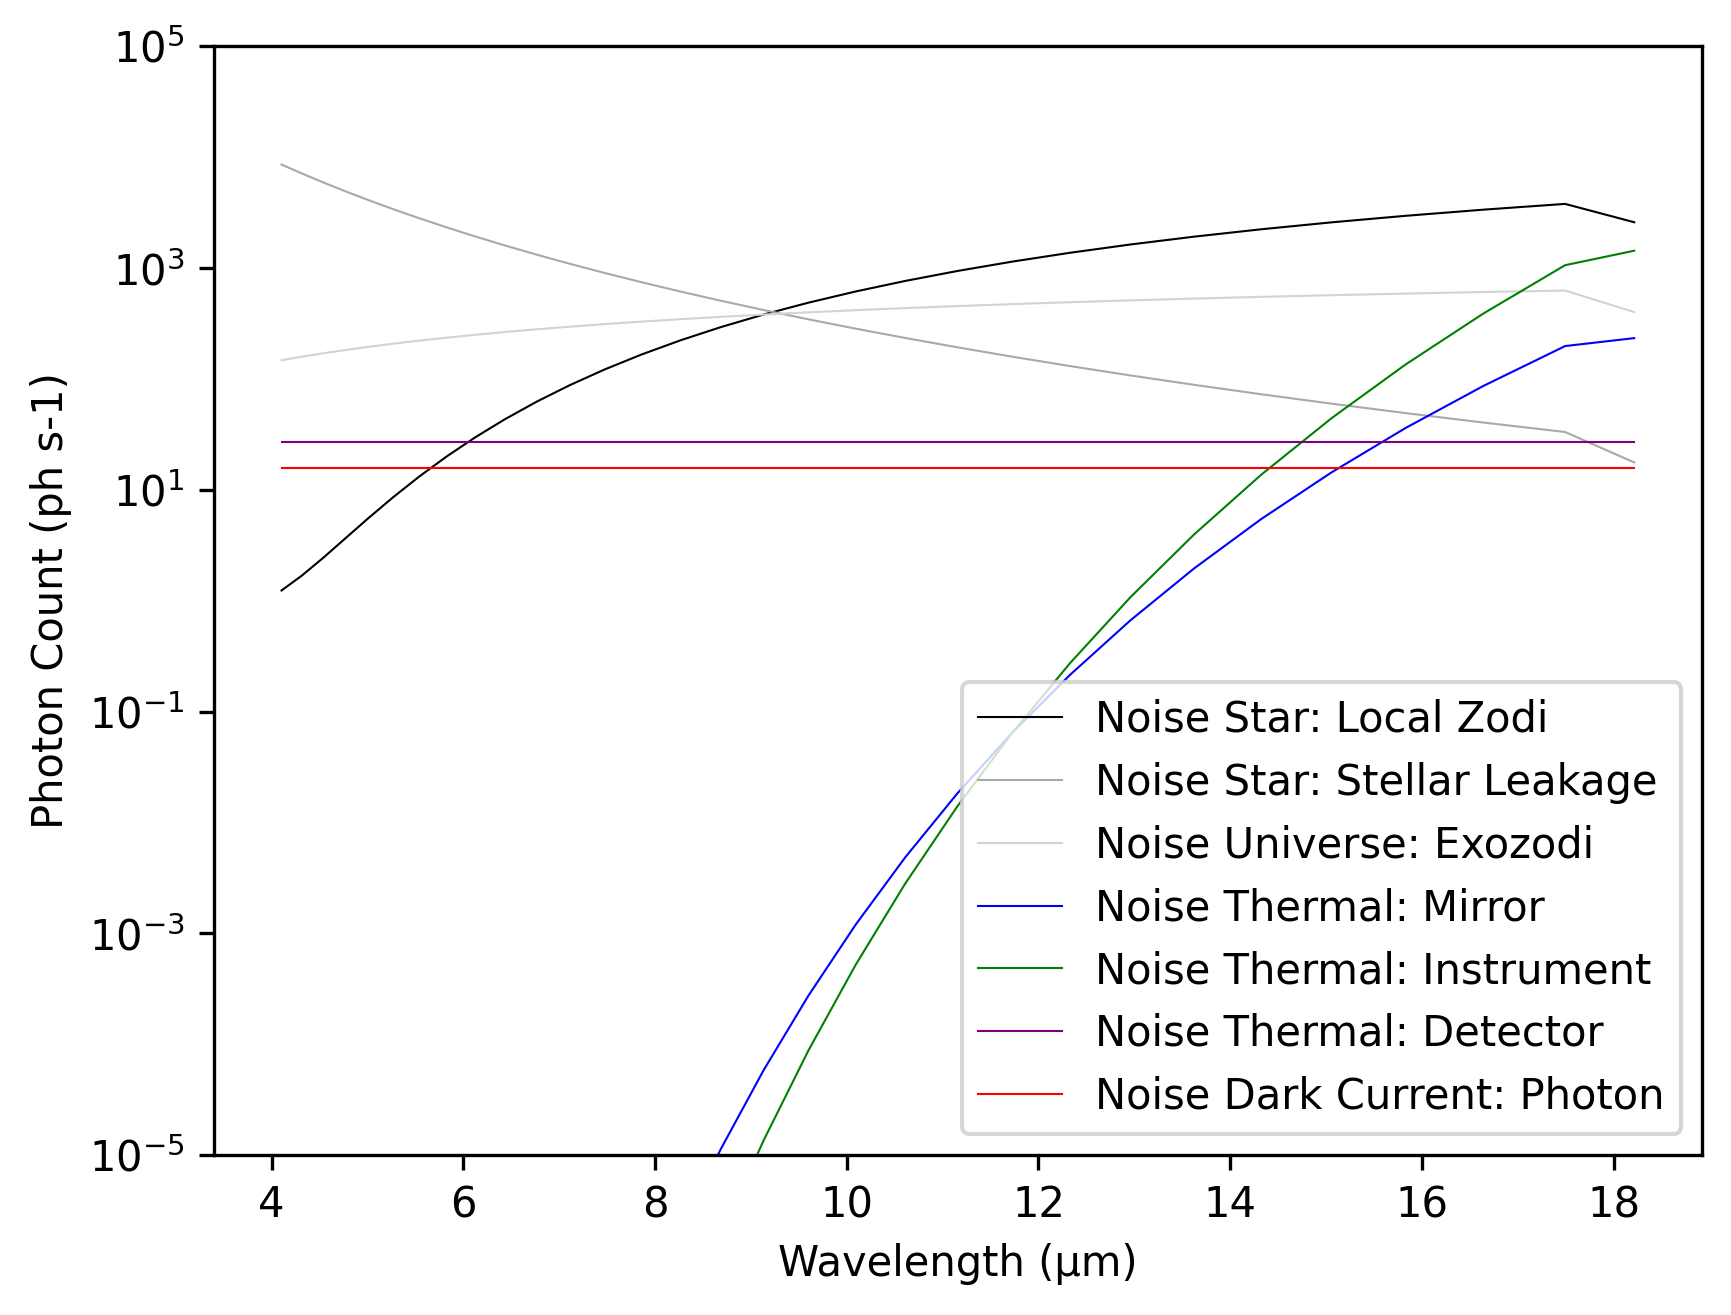

In [37]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')

ln1 = plt.plot(x, noise_star_local, lw=0.5, c='black', label='Noise Star: Local Zodi')
ln2 = plt.plot(x, noise_star_starleak, lw=0.5, c='darkgray', label='Noise Star: Stellar Leakage')
ln3 = plt.plot(x, noise_universe, lw=0.5, c='lightgray', label='Noise Universe: Exozodi')

ln4 = plt.plot(x, noise_thermal_mirror, lw=0.5, c='blue', label='Noise Thermal: Mirror')
ln7 = plt.plot(x, noise_thermal_inst, lw=0.5, c='green', label='Noise Thermal: Instrument')
ln5 = plt.plot(x, noise_thermal_detector, lw=0.5, c='purple', label='Noise Thermal: Detector')
ln6 = plt.plot(x, noise_dc_photon, lw=0.5, c='red', label='Noise Dark Current: Photon')

lns = ln1 + ln2 + ln3 + ln4  + ln7 + ln5 + ln6 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e-5, 1e5)

plt.show()

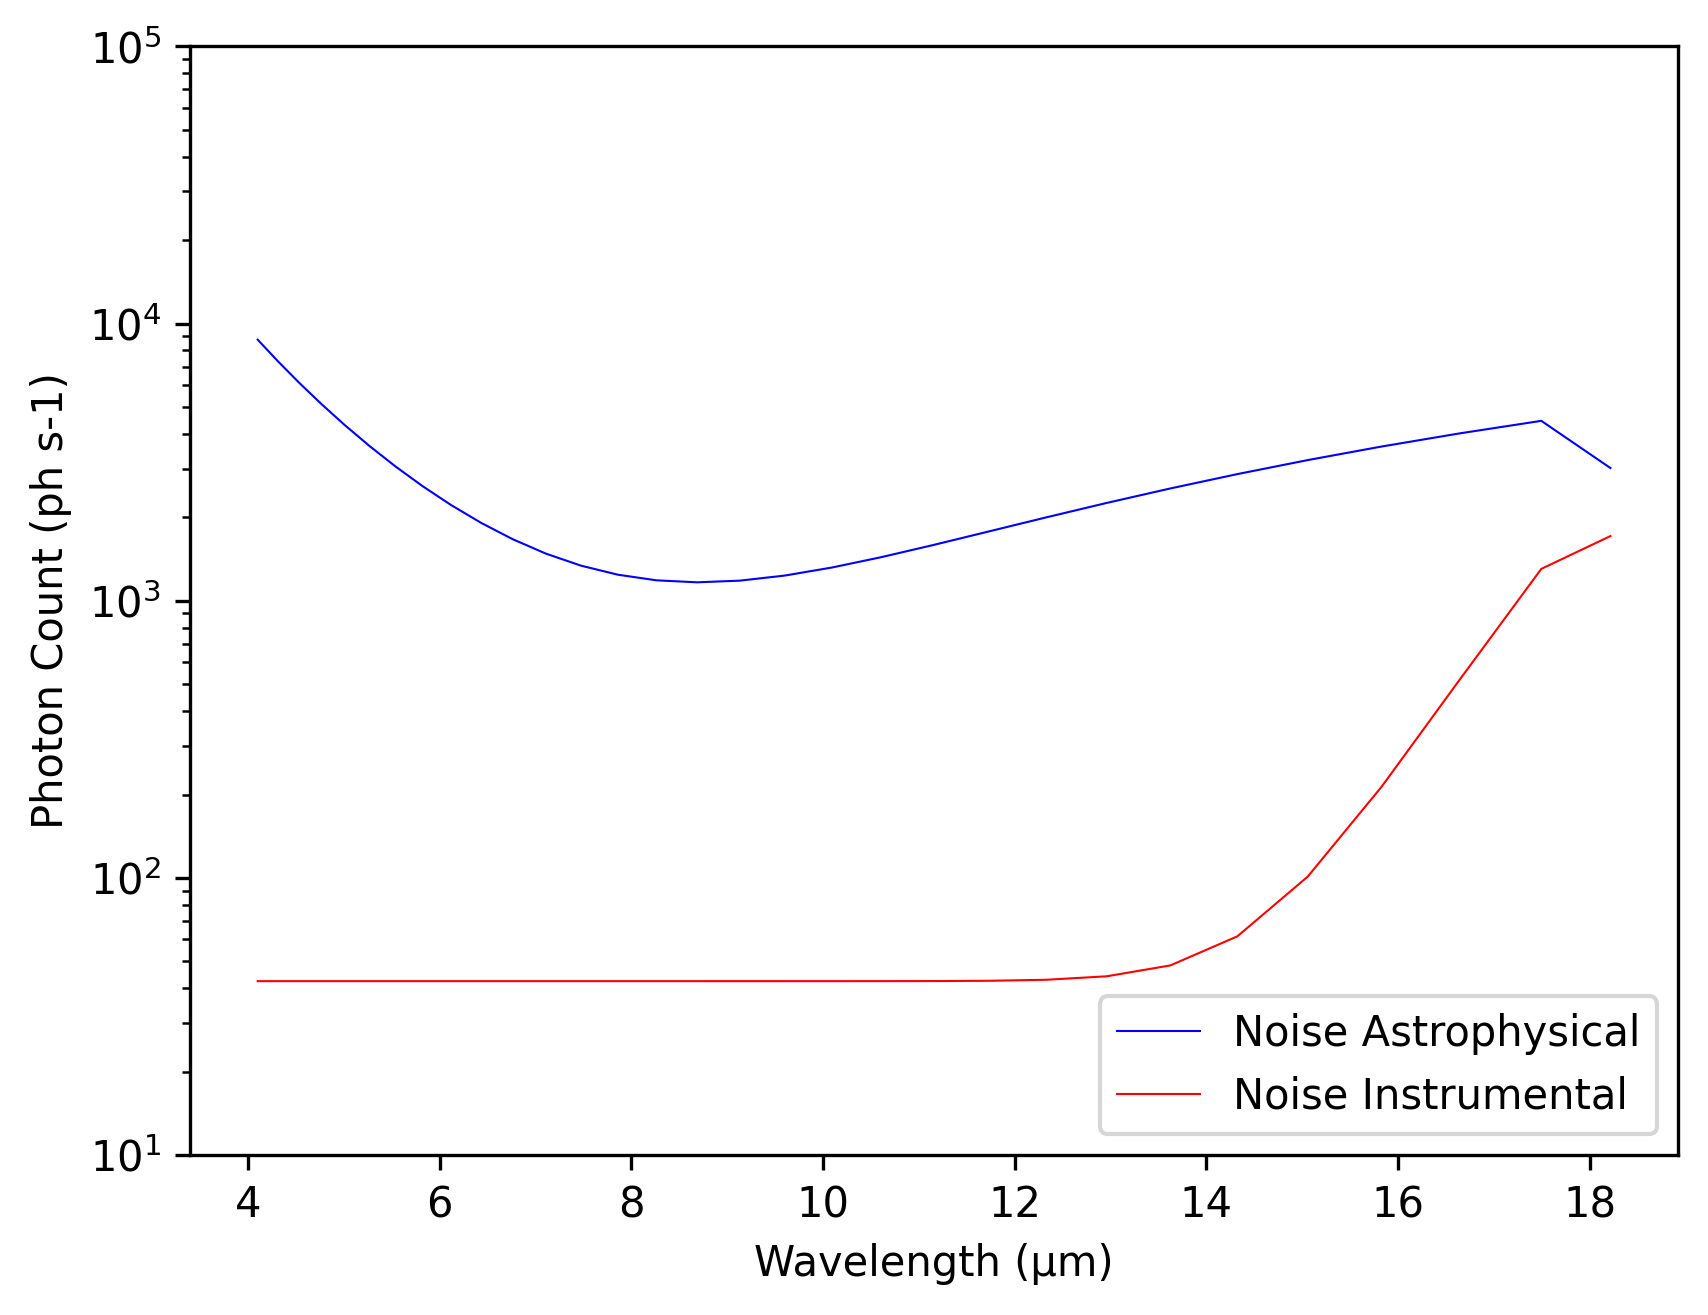

In [42]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(x, noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(x, noise_planet, lw=0.5, c='gray', label='Noise Planet')

noise_astrophysical = noise_star_local + noise_star_starleak + noise_universe
noise_instrumental = noise_thermal_mirror + noise_thermal_detector + noise_thermal_inst + noise_dc_photon

ln1 = plt.plot(x, noise_astrophysical, lw=0.5, c='blue', label='Noise Astrophysical')
ln2 = plt.plot(x, noise_instrumental, lw=0.5, c='red', label='Noise Instrumental')

lns = ln1 + ln2 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e1, 1e5)

plt.show()

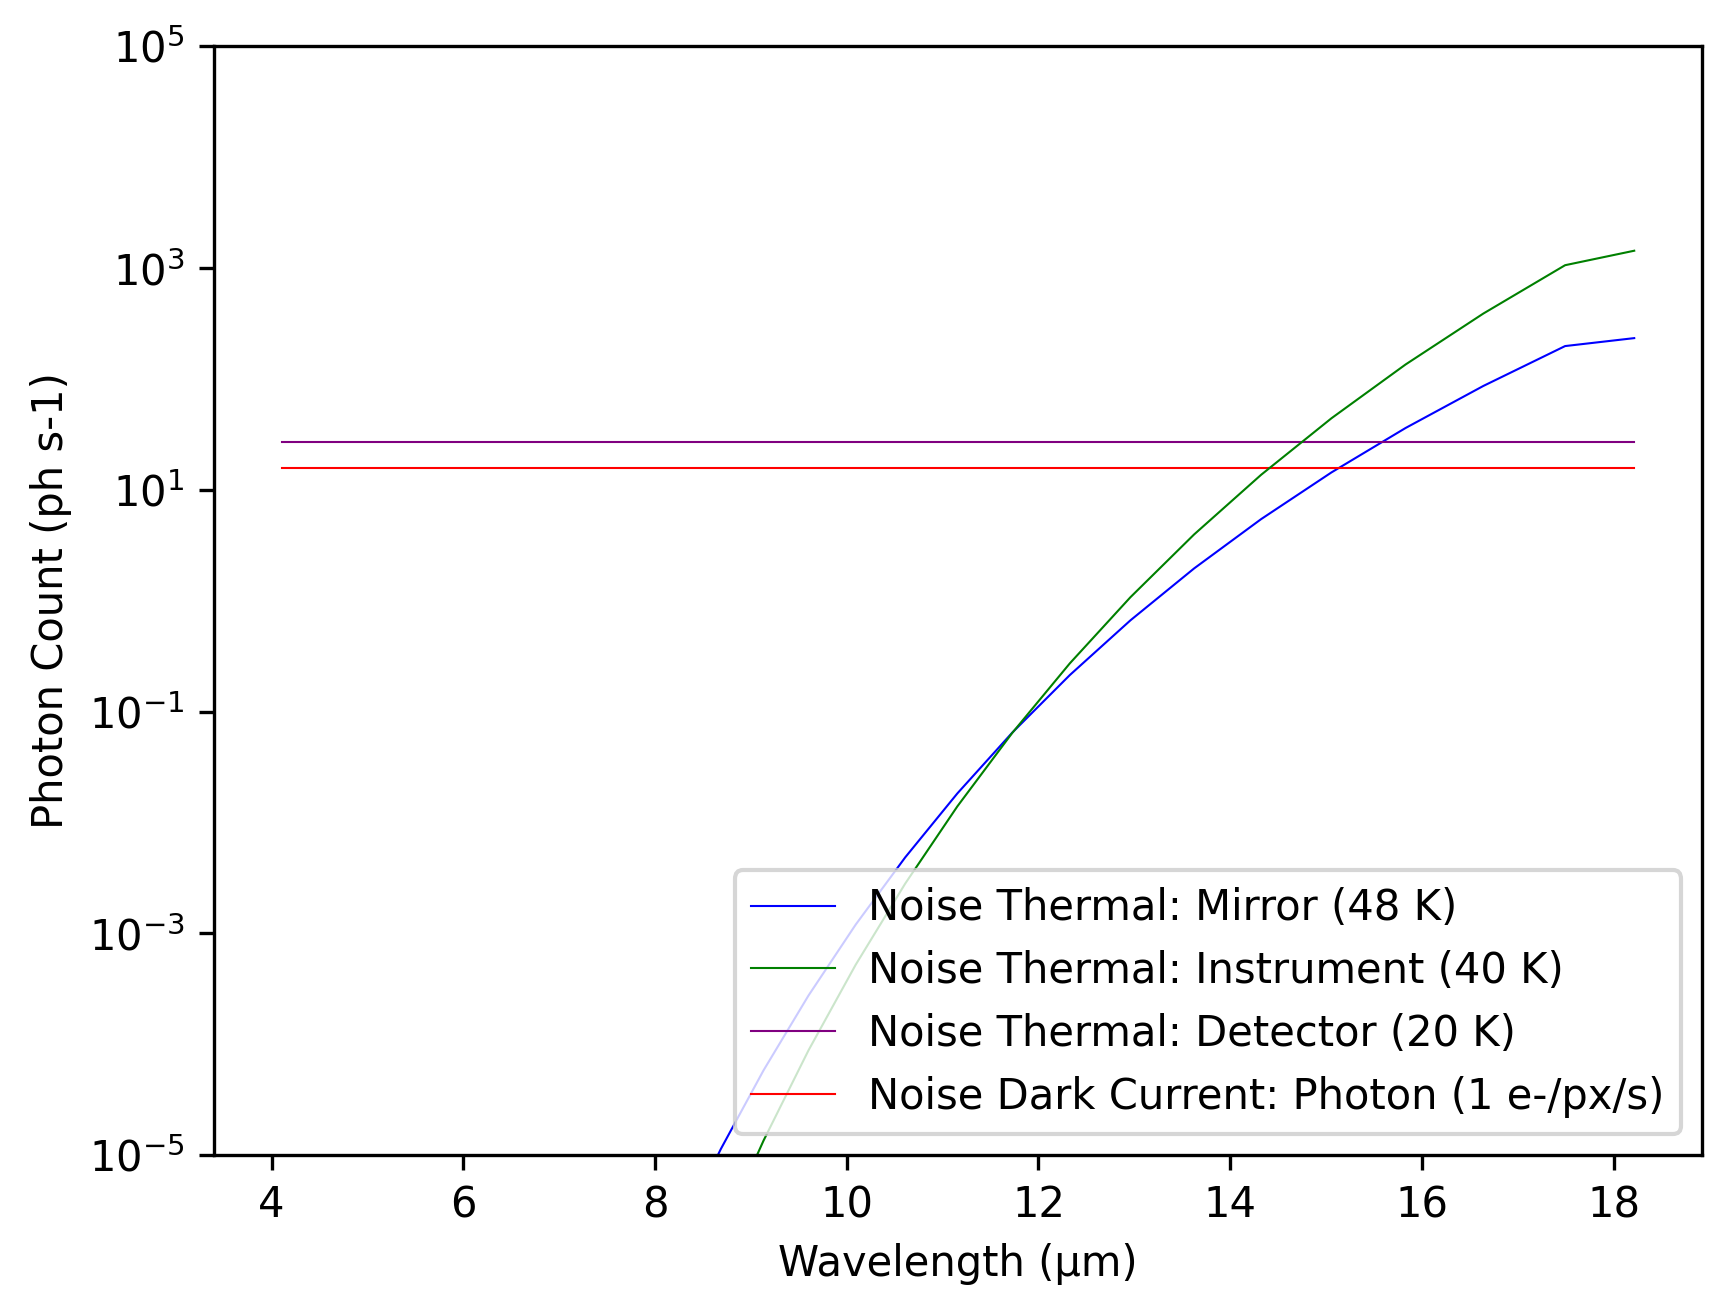

In [38]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')


ln4 = ax.plot(x, noise_thermal_mirror, lw=0.5, c='blue', label=f'Noise Thermal: Mirror ({bus.data.options.thermal["ota_temperature"]} K)')
ln5 = ax.plot(x, noise_thermal_detector, lw=0.5, c='purple', label=f'Noise Thermal: Detector ({bus.data.options.thermal["detector_temperature"]} K)')
ln6 = ax.plot(x, noise_dc_photon, lw=0.5, c='red', label=f'Noise Dark Current: Photon ({bus.data.options.array["dc_per_pix"]} e-/px/s)')
ln7 = ax.plot(x, noise_thermal_inst, lw=0.5, c='green', label=f'Noise Thermal: Instrument ({bus.data.options.thermal["instrument_temperature"]} K)')

lns = ln4 + ln7 + ln5 + ln6 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax2.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e-5, 1e5)

plt.show()

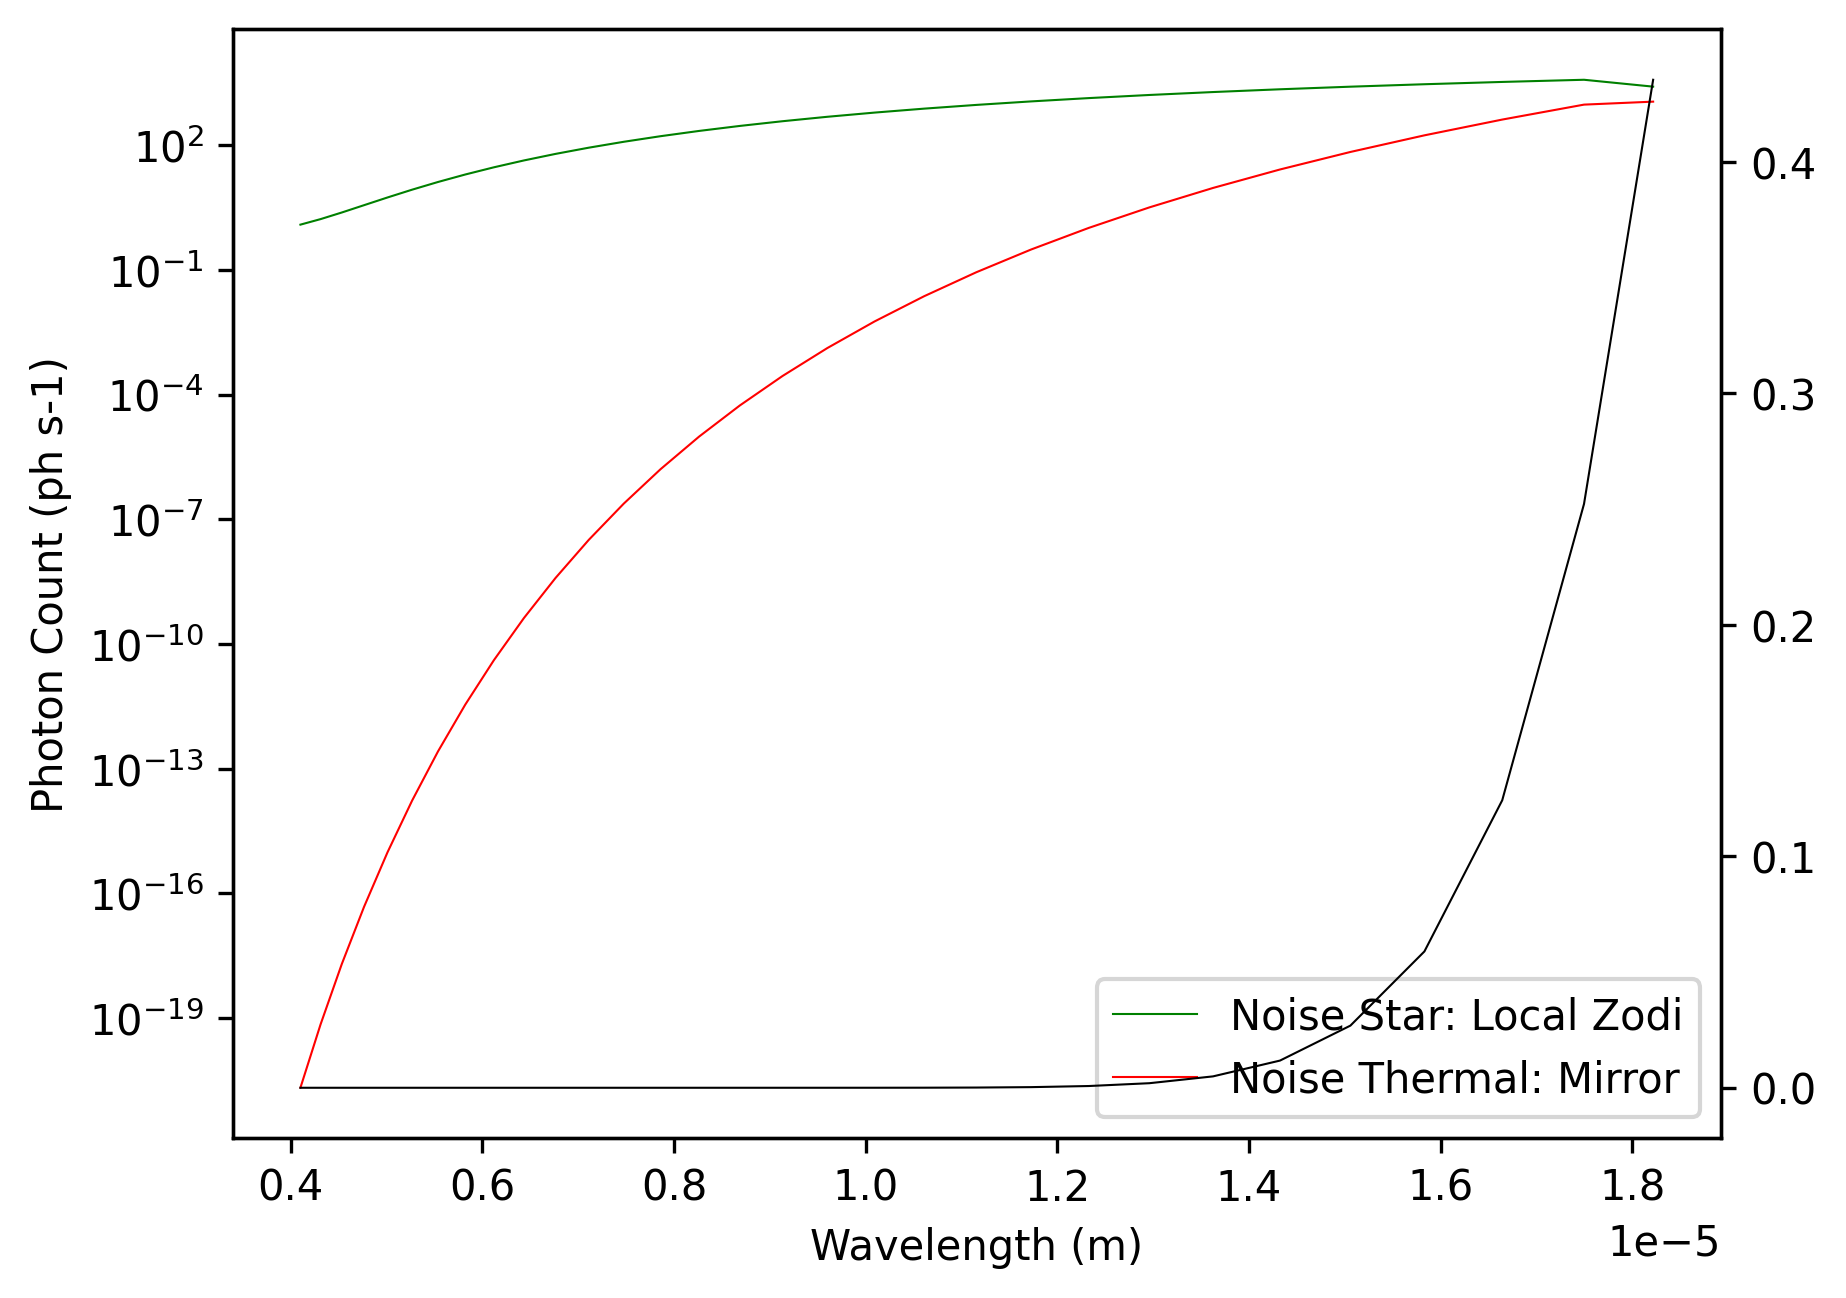

In [21]:
fig, ax = plt.subplots(dpi=300)

ln1 = plt.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')

ln4 = plt.plot(spectrum_tmo[0], noise_thermal_mirror, lw=0.5, c='red', label='Noise Thermal: Mirror')

ax2=ax.twinx()
lncomp = ax2.plot(spectrum_tmo[0], noise_thermal_mirror/noise_star_local, lw=0.5, c='black', label='Noise Star + Thermal Mirror')

lns = ln1 + ln4
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1)")

plt.show()

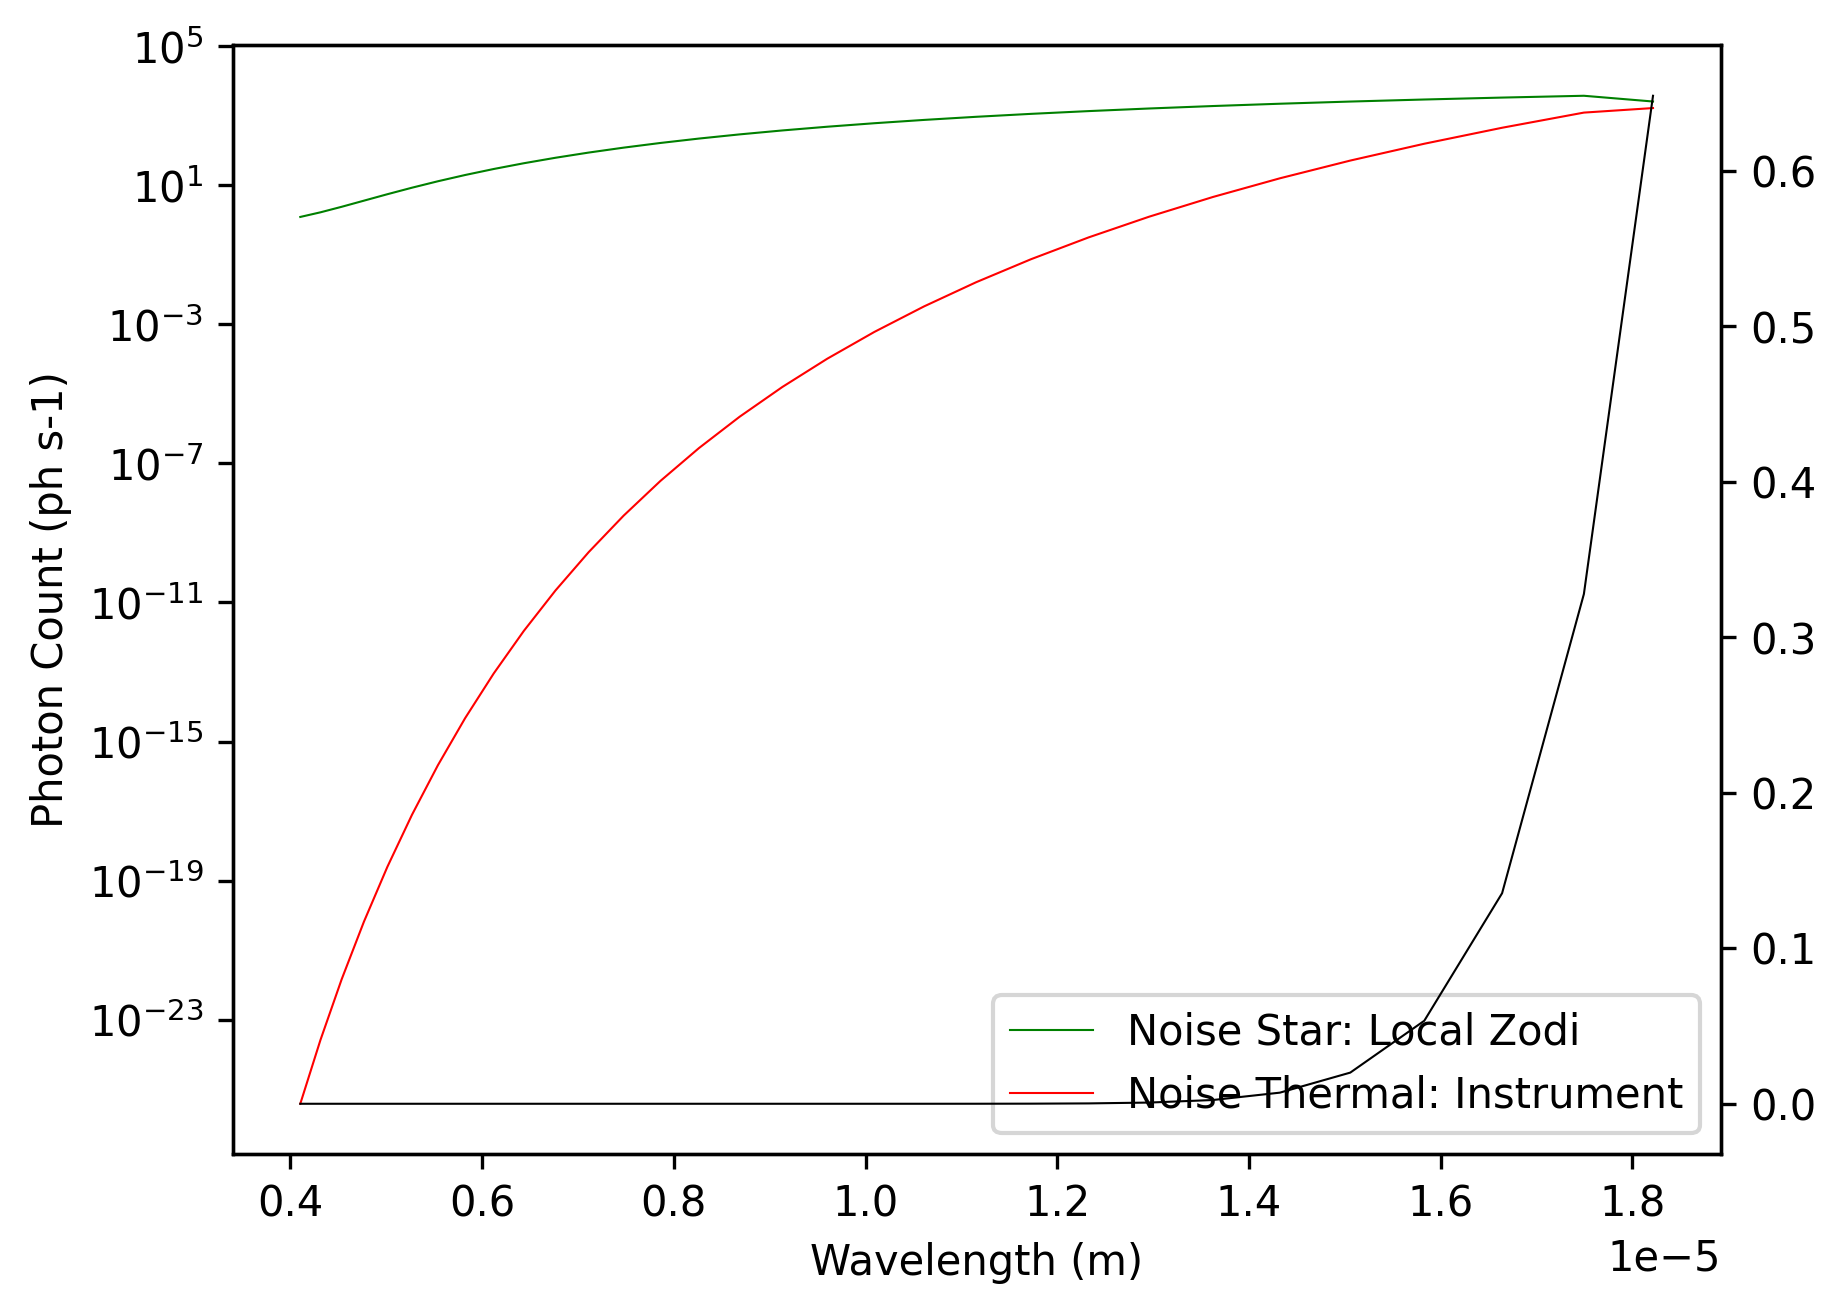

In [22]:
fig, ax = plt.subplots(dpi=300)

ln1 = plt.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='green', label='Noise Star: Local Zodi')

ln4 = plt.plot(spectrum_tmo[0], noise_thermal_inst, lw=0.5, c='red', label='Noise Thermal: Instrument')

ax2=ax.twinx()
lncomp = ax2.plot(spectrum_tmo[0], noise_thermal_inst/noise_star_local, lw=0.5, c='black', label='Noise Star + Thermal Instrument')

lns = ln1 + ln4
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1)")

plt.show()

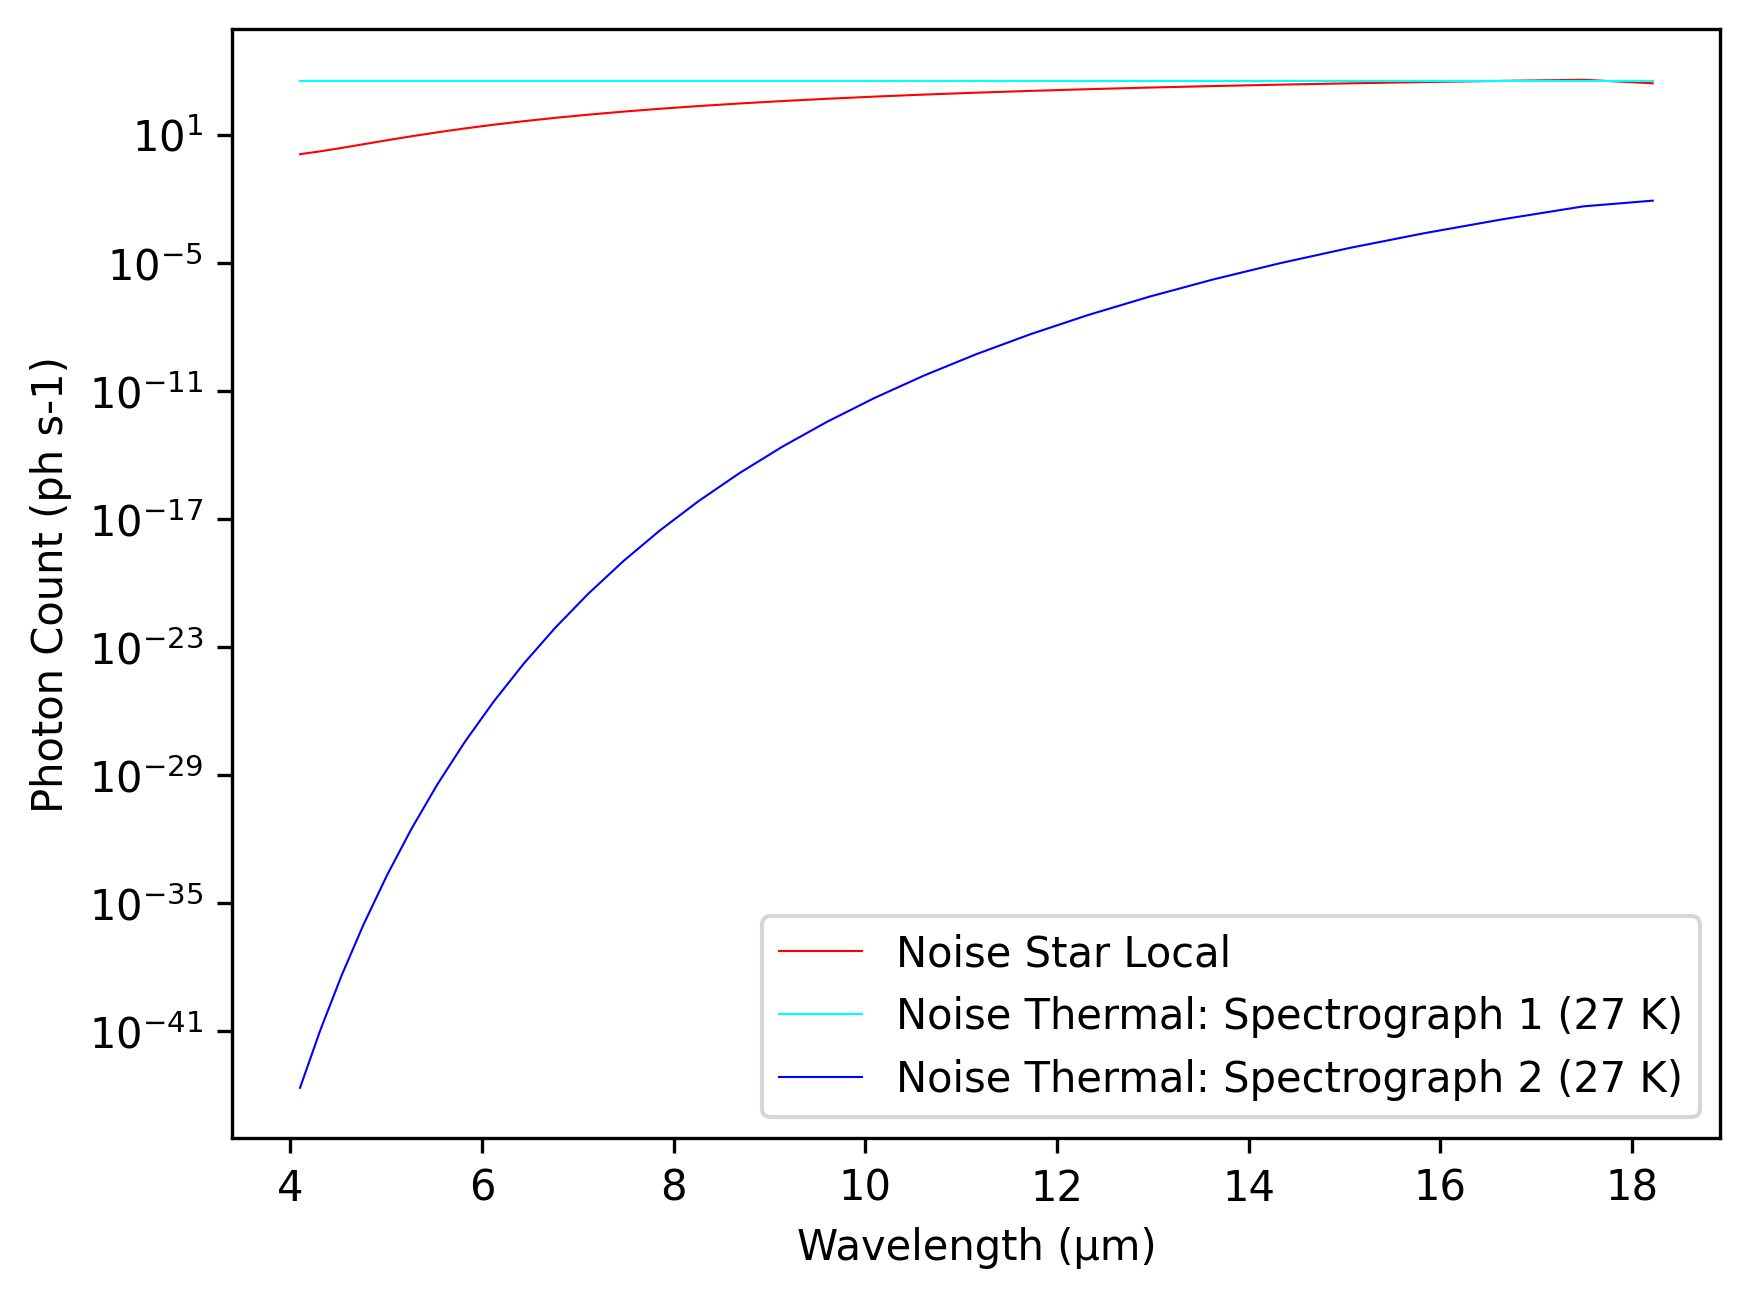

In [23]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')


ln4 = ax.plot(x, noise_star_local, lw=0.5, c='red', label=f'Noise Star Local')
ln8 = ax.plot(x, noise_thermal_spectro_1, lw=0.5, c='cyan', label=f'Noise Thermal: Spectrograph 1 ({bus.data.options.array["spectro_temp"]} K)')
ln9 = ax.plot(x, noise_thermal_spectro_2, lw=0.5, c='blue', label=f'Noise Thermal: Spectrograph 2 ({bus.data.options.array["spectro_temp"]} K)')

lns = ln4 + ln8 + ln9 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax2.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
# ax.set_ylim(1e-5, 1e5)

plt.show()

In [28]:
# Band-integrated spectrograph noise (pre-disperser), over full band
spec_band = noise_thermal_spectro_2.sum()      # ph s^-1

# Zodi noise in the shortest wavelength bin (first bin)
zodi_short_bin = noise_star_local[0]           # ph s^-1

ratio = spec_band / zodi_short_bin
print("Integrated spectro 2 / shortest zodi bin =", ratio)

Integrated spectro 2 / shortest zodi bin = 0.011402317320544598


# thermal noise verification

skip all this as some functions are not defined, for testing

## jonah

In [48]:
from astropy.modeling import models
from astropy import constants, units as u
#from jwst_backgrounds import jbt
import numpy as np
#from scipy.interpolate import interp1d
from astropy import constants as const
from scipy.optimize import minimize_scalar
from scipy.integrate import quad

import numpy as np
from typing import Union

from lifesim.util import constants

h = const.h.value #Planck constant

In [49]:
def BB(T,w):
    bb = models.BlackBody(temperature=T*u.K, scale=1.0 * u.ph / (u.m ** 2 * u.micron * u.s * u.sr))
    return bb(w*u.micron)

def integrate_BB(T,w_min,w_max):
    waves = np.linspace(w_min,w_max,10000)
    BBs = BB(T,waves)
    ret = np.trapz(x=waves*u.micron, y=BBs).to('ph s-1 m-2 sr-1')
    return ret



def compare_zod(T,w,e,Z_T,Z_OD):
    return BB(T,w)*e/(BB(Z_T,w)*Z_OD)

def find_temp(target_factor,w,e,Z_T,Z_OD):
    def test_func(T):
        x = compare_zod(T,w,e,Z_T,Z_OD)-target_factor
        return np.abs(x)
    res = minimize_scalar(test_func,bounds=(1,60), method='bounded')
    return np.round(res.x,1)

def find_temp2(target_factor,w_min,w_max,zod):
    def test_func(T):
        x = integrate_BB(T,w_min,w_max)/zod-target_factor
        return np.abs(x)
    res = minimize_scalar(test_func,bounds=(1,60), method='bounded')
    return np.round(res.x,1)

In [50]:
Z_temp = 265 # 286
Z_OD = 1e-7
short_wave = 4 #microns
long_wave = 18.5 #microns

resolution = 100
L_detector = 18.5
NA = 0.33

mirror_emissivity = 0.025
bc_emissivity = 1

better_than_factor = 1/3

T_mirror = find_temp(better_than_factor,long_wave,mirror_emissivity,Z_temp,Z_OD)
T_scattering = find_temp(better_than_factor,long_wave,bc_emissivity,Z_temp,Z_OD)
Zod_radiance_at_shortest_wavelength = Z_OD*integrate_BB(Z_temp,short_wave,short_wave+short_wave/resolution)
T_spectrograph = find_temp2(better_than_factor*NA**2,short_wave,L_detector,Zod_radiance_at_shortest_wavelength)
#T_detector = find_temp(better_than_factor/resolution/2/np.pi,L_detector,1,Z_temp,Z_OD)
T_detector = find_temp2(better_than_factor*NA**2/2/np.pi,short_wave,L_detector,Zod_radiance_at_shortest_wavelength)

AttributeError: module 'numpy' has no attribute 'trapz'

In [51]:
print(f"Zodiacal background is at {Z_temp} K with an optical depth of {Z_OD}")
print("")

print(f"Mirrors should be at a temperature where the emissivity is less than the zodiacal background at longest wavelength")
print(f"Mirror should be at a temperature of {T_mirror} K")
print(f"")

print(f"bb of zodiacal background at longest wavelength is {BB(Z_temp,long_wave)} ph s-1 m-2 sr-1 um-1 ")
print(f"same with lifesim formula is {black_body(mode='wavelength', bins=np.array([long_wave*1e-6]), width=np.array([long_wave*1e-6/resolution]), temp=Z_temp)} ph s-1 m-2 sr-1 um-1")

print(f"Fibre sees more thermal background than just the mirror, as BC has ~100% emissivity")
print(f"Scattering from the BC leads to a temperature of {T_scattering} K")
print(f"")

print(f"Spectrograph has a resolution of {resolution}, and short channels are sensitive to long wave background")
print(f"The spectrograph should be at a temperature of {T_spectrograph} K")
print("")

print(f"The detector sees the hemisphere of a very cold stop, and also has a different cutoff wavelength of {L_detector} um")
print(f"The temperature of the very cold stop must be {T_detector} K")
print("")

print(f"Finally the detector must also be cooled down (likely on the level of <10 K)")

Zodiacal background is at 265 K with an optical depth of 1e-07

Mirrors should be at a temperature where the emissivity is less than the zodiacal background at longest wavelength
Mirror should be at a temperature of 47.4 K

bb of zodiacal background at longest wavelength is 2.8728929332776894e+20 ph / (micron s sr m2) ph s-1 m-2 sr-1 um-1 
same with lifesim formula is [5.31486935e+19] ph s-1 m-2 sr-1 um-1
Fibre sees more thermal background than just the mirror, as BC has ~100% emissivity
Scattering from the BC leads to a temperature of 38.7 K

Spectrograph has a resolution of 100, and short channels are sensitive to long wave background


NameError: name 'T_spectrograph' is not defined

In [52]:
bin_width_um = long_wave / resolution
bb_per_um = BB(Z_temp, long_wave)                          # Quantity: ph / (m2 µm s sr)
bb_per_bin = (bb_per_um * (bin_width_um * u.um)).to('ph s-1 m-2 sr-1')

lifesim_bb = black_body(
    mode='wavelength',
    bins=np.array([long_wave * 1e-6]),
    width=np.array([long_wave * 1e-6 / resolution]),
    temp=T_mirror
)[0]

print("BB (per µm) =", bb_per_um)
print("BB integrated over bin =", bb_per_bin)
print("black_body (lifesim) per bin =", lifesim_bb)
print(f"emission of mirror considering emissivity and stuff is {mirror_emissivity*np.pi*7.85e-7*lifesim_bb} ph s-1 m-2 sr-1")

BB (per µm) = 2.8728929332776894e+20 ph / (micron s sr m2)
BB integrated over bin = 5.314851926563725e+19 ph / (s sr m2)
black_body (lifesim) per bin = 70899530168799.33
emission of mirror considering emissivity and stuff is 4371222.321254882 ph s-1 m-2 sr-1


In [53]:
np.sqrt(
                np.pi / np.arccos(np.cos(3 / 4 * np.pi) * np.cos(bus.data.single['lat'])) /
                (np.sin(bus.data.single['lat']) ** 2
                 + (0.6 * (bus.data.inst['wl_bins'] / 11e-6) ** (-0.4) * np.cos(bus.data.single['lat'])) ** 2)
            )

array([1.2935592 , 1.30506038, 1.31640451, 1.32758717, 1.33860419,
       1.3494517 , 1.36012615, 1.37062428, 1.38094313, 1.39108007,
       1.40103276, 1.41079916, 1.42037755, 1.42976651, 1.43896489,
       1.44797187, 1.45678686, 1.46540961, 1.47384007, 1.4820785 ,
       1.49012539, 1.49798146, 1.50564767, 1.5131252 , 1.52041544,
       1.52751994, 1.53444049, 1.54117901, 1.54773759, 1.55411848,
       1.55914452])

TypeError: black_body() missing 2 required positional arguments: 'width' and 'temp'

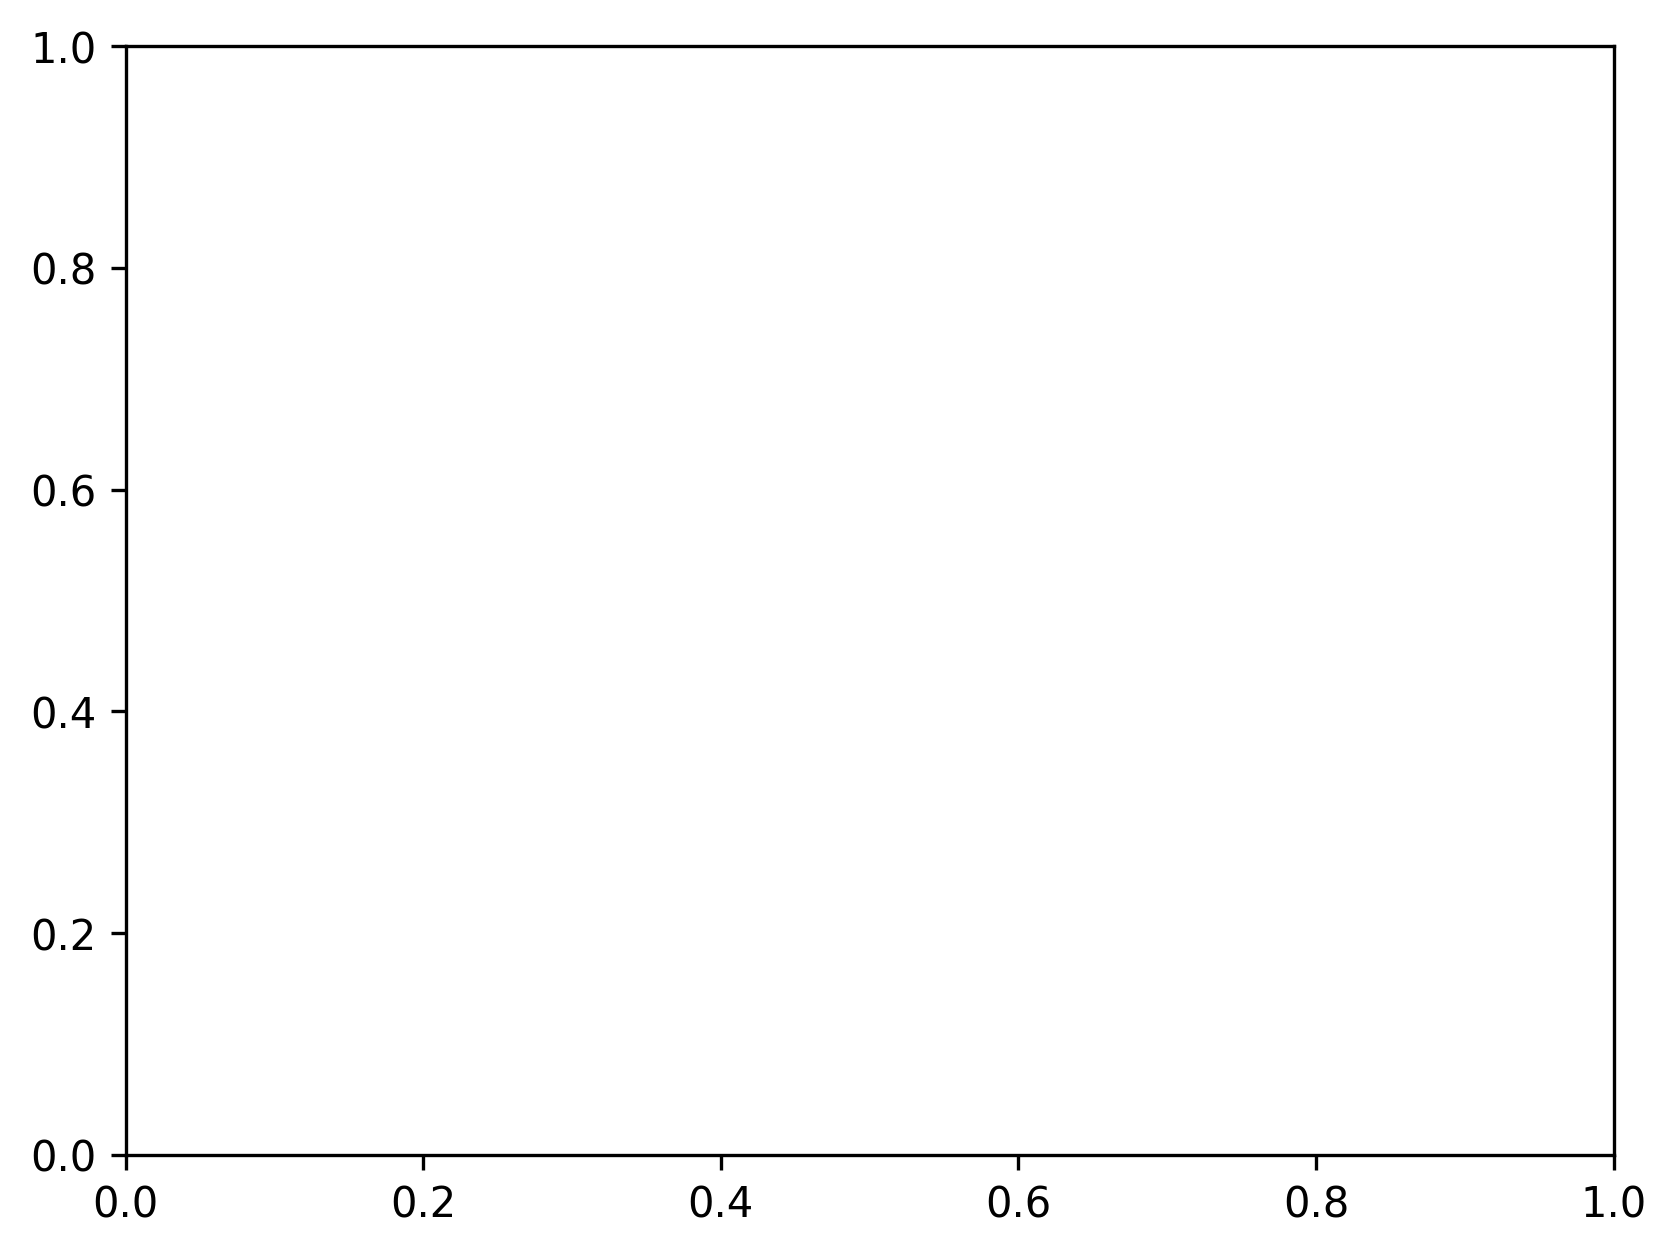

In [54]:
from lifesim.util.radiation import black_body as BB

fig, ax = plt.subplots(dpi=300)

waves_um = bus.data.inst['wl_bins']*1e6
bb_mirror = BB(48, waves_um)*mirror_emissivity
bb_zodiac = BB(Z_temp, waves_um)*Z_OD
bb_tot = (BB(265, waves_um) + 0.22 * BB(5778, waves_um)) * (0.00465047 / 1.5) ** 2 * 4e-8
bb_tot2 = (0.22 * BB(5778, waves_um)) * (0.00465047 / 1.5) ** 2 * 4e-8
bb_tot3 = (BB(265, waves_um)) * (0.00465047 / 1.5) ** 2 * 4e-8

ax.plot(waves_um, bb_mirror.value, c="red", lw=1.0, label=f"BB(T={T_mirror.value} K)")
ax.plot(waves_um, bb_zodiac.value, c="blue", lw=1.0, label=f"BB(T={Z_temp} K)")
ax.plot(waves_um, bb_tot.value, c="black", lw=1.0, label="LIFEsim Zodiacal Noise BB")
ax.plot(waves_um, bb_tot2.value, c="orange", lw=1.0, label="LIFEsim Zodiacal Noise BB (Sun)")
ax.plot(waves_um, bb_tot3.value, c="purple", lw=1.0, label="LIFEsim Zodiacal Noise BB (Zodiacal)")
ax2 = ax.twinx()
ax2.plot(waves_um, bb_mirror.value/bb_zodiac.value, c="green", lw=1.0, label="Ratio Mirror/Zodiac")

ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel(f"Spectral radiance ({bb_mirror.unit})")
ax.set_yscale("log")
ax.legend(loc='lower left')
ax2.legend(loc='lower right')

plt.show()

## lifesim comparison

In [55]:
mirror_area = np.pi * (bus.data.options.array['diameter'] / 2.) ** 2
beam_radius = bus.data.options.array['beam_size']/2
distance = 2.5 * bus.data.options.array['diameter']
solid_angle = (np.pi * beam_radius ** 2) / (distance ** 2)

KeyError: 'beam_size'

In [ ]:
# mirror black body comparison
waves_um = bus.data.inst['wl_bins']*1e6
bb_48K = BB(48, waves_um)
backtracked_thermalnoise = noise_thermal_mirror/(mirror_area * solid_angle * bus.data.options.array['m_emissivity'])

fig, ax = plt.subplots(dpi=300)
ax.plot(waves_um, bb_48K.value, c="red", lw=1.0, label="BB(T=48 K)")
ax.plot(waves_um, backtracked_thermalnoise, c="blue", lw=1.0, label="LIFEsim Mirror Thermal Noise")
ax2 = ax.twinx()
ax2.plot(waves_um, bb_48K.value/backtracked_thermalnoise, c="green", lw=1.0, label="Ratio BB/LIFEsim")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel(f"Spectral radiance ({bb_48K.unit})")
ax.set_yscale("log")
ax.legend()
ax2.legend()
plt.show()

TypeError: black_body() missing 2 required positional arguments: 'width' and 'temp'

: 

: 

In [ ]:
# zodiacal background
Z_OD = 1e-7
waves_um = bus.data.inst['wl_bins']*1e6
bb_LZ = BB(286, waves_um)*Z_OD
bb_tot = (BB(265, waves_um) + 0.22 * BB(5778, waves_um)) * (0.00465047 / 1.5) ** 2 * 4e-8

fig, ax = plt.subplots(dpi=300)
ax.plot(waves_um, bb_LZ.value, c="red", lw=1.0, label="BB(T=286 K)")
ax.plot(waves_um, bb_tot.value, c="blue", lw=1.0, label="LIFEsim Zodiacal Noise")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel(f"Spectral radiance ({bb_LZ.unit})")
ax.set_yscale("log")
ax.legend()
plt.show()



TypeError: black_body() missing 2 required positional arguments: 'width' and 'temp'

: 

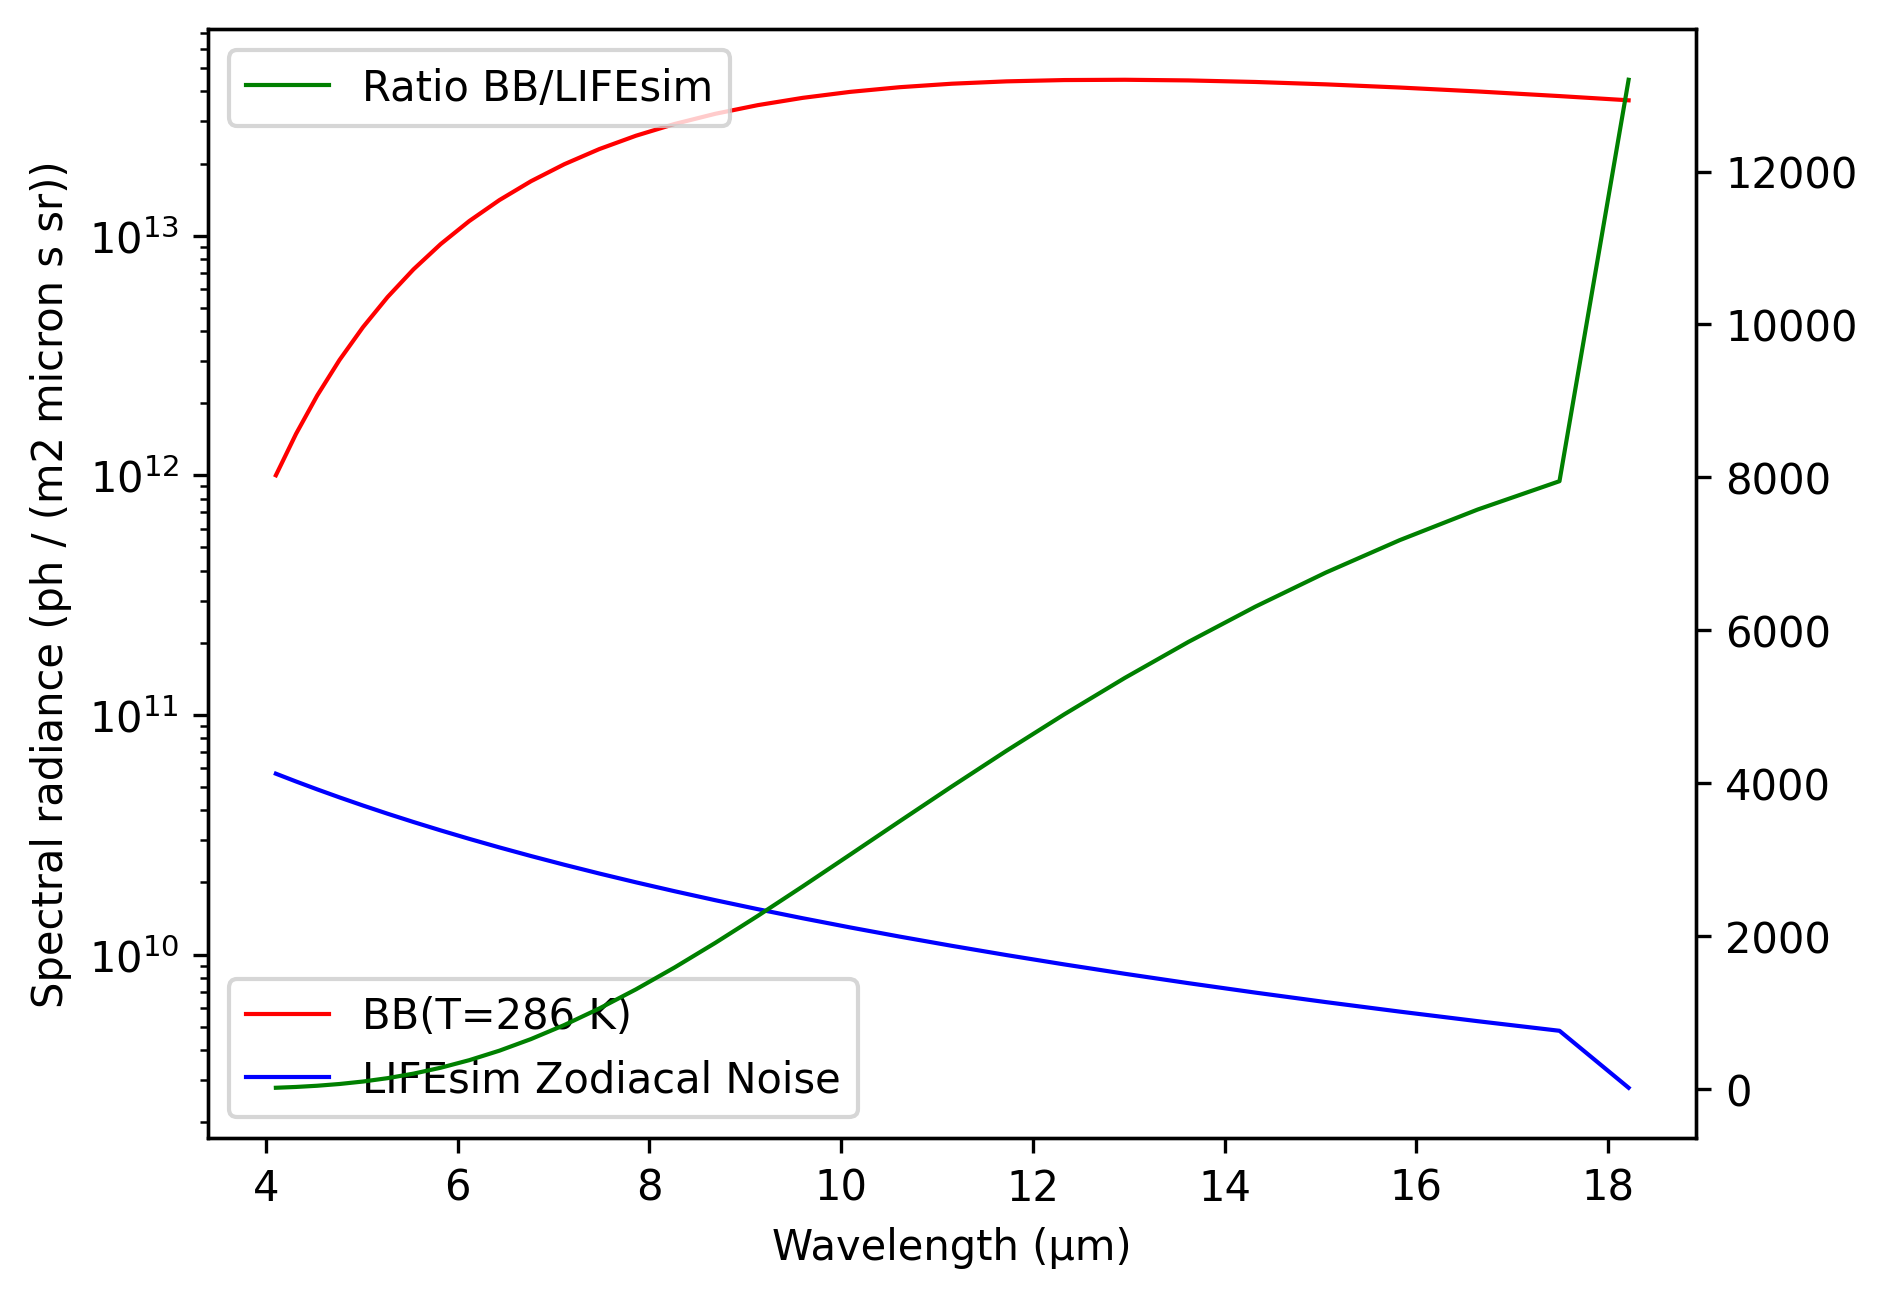

: 

: 

In [ ]:
# zodiacal background
Z_OD = 1e-7
waves_um = bus.data.inst['wl_bins']*1e6
bb_LZ = BB(286, waves_um)*Z_OD
solid_angle_zodiac = (np.pi * (bus.data.inst['image_angle']) ** 2)
ap = np.ones_like(bus.data.inst['radius_map'])
backtracked_zodiacnoise = noise_star_local/(mirror_area * 4 * solid_angle_zodiac * (ap * bus.data.inst['t_map']).sum(axis=(-2, -1)) / ap.sum())

fig, ax = plt.subplots(dpi=300)
ax.plot(waves_um, bb_LZ.value, c="red", lw=1.0, label="BB(T=286 K)")
ax.plot(waves_um, backtracked_zodiacnoise, c="blue", lw=1.0, label="LIFEsim Zodiacal Noise")
ax2 = ax.twinx()
ax2.plot(waves_um, bb_LZ.value/backtracked_zodiacnoise, c="green", lw=1.0, label="Ratio BB/LIFEsim")
ax.set_xlabel("Wavelength (µm)")
ax.set_ylabel(f"Spectral radiance ({bb_LZ.unit})")
ax.set_yscale("log")
ax.legend()
ax2.legend()
plt.show()

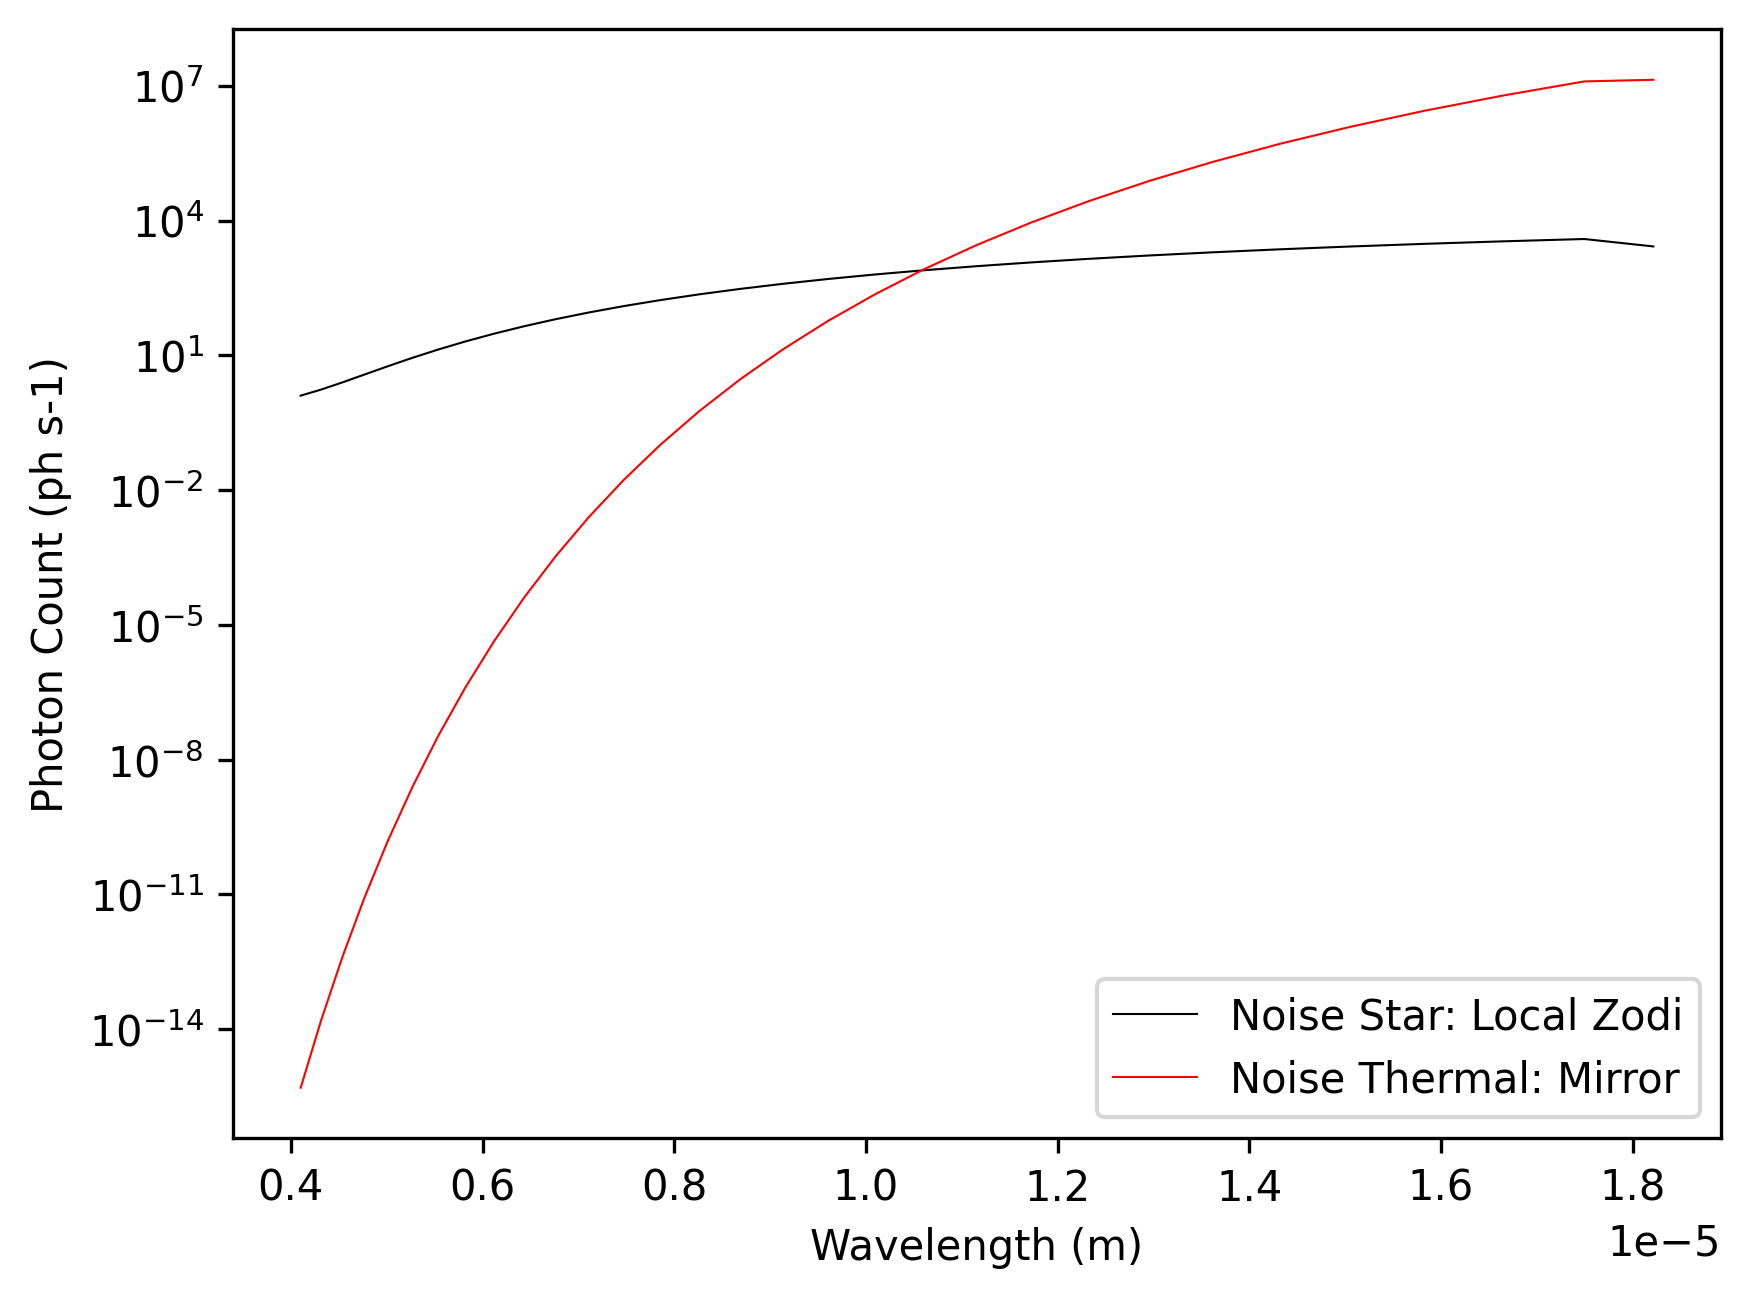

: 

: 

In [ ]:
# only thermal noise and local zodi
fig, ax = plt.subplots(dpi=300)

ln1 = ax.plot(spectrum_tmo[0], noise_star_local, lw=0.5, c='black', label='Noise Star: Local Zodi')
ln2 = ax.plot(spectrum_tmo[0], noise_thermal_mirror, lw=0.5, c='red', label='Noise Thermal: Mirror')

lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Photon Count (ph s-1)")

plt.show()

# conversion to jwst plot units

In [56]:
def photons_to_mjy_sr_old(R, lam, dl, area, omega, eff=1.0):
    h = const.h # Planck constant in J s
    c = const.c # Speed of light in m/s
    N_lambda = R / (area * omega * dl * eff)
    L_lambda = N_lambda * h * c / lam
    L_nu     = L_lambda.to(u.W / (u.m**2 * u.Hz * u.sr), equivalencies=u.spectral_density(lam))
    return L_nu.to(u.MJy / u.sr)


In [57]:
noise_star_local_unit = noise_star[0] / u.s
noise_thermal_mirror_unit = noise_thermal[0] / u.s

lam = bus.data.inst['wl_bins'] * u.m
dl = bus.data.inst['wl_bin_widths'] * u.m
area = np.pi * (bus.data.options.array['diameter'] / 2.) ** 2 * u.m**2

omega = ((np.pi * (bus.data.options.array['beam_size']/2)**2) / ((2.5 * bus.data.options.array['diameter'])**2 )) * u.sr
omega_localzodi = np.pi * (np.tan(bus.data.inst['wl_bins']/2/bus.data.options.array['diameter']))**2 *u.sr
omega_localzodi_old = (np.pi * bus.data.inst['image_angle'] ** 2) * u.sr

KeyError: 'beam_size'

In [58]:
print(omega_localzodi)
print((np.pi * bus.data.inst['image_angle'] ** 2))
print(omega_localzodi/(np.pi * bus.data.inst['image_angle'] ** 2))

NameError: name 'omega_localzodi' is not defined

In [59]:
def photons_to_mjy(R, lam, dl, area, eff=1.0):
    h = const.h # Planck constant in J s
    c = const.c # Speed of light in m/s
    N_lambda = R / (area * dl * eff)
    L_lambda = N_lambda * h * c / lam
    L_nu     = L_lambda.to(u.W / (u.m**2 * u.Hz), equivalencies=u.spectral_density(lam))
    return L_nu.to(u.MJy)


In [65]:
omega = np.pi * (bus.data.inst['hfov'])**2

In [63]:
noise_star_local_mjy = photons_to_mjy(noise_star_local_unit, lam, dl, area, eff=1)
noise_thermal_mirror_mjy = photons_to_mjy(noise_thermal_mirror_unit, lam, dl, area, eff=bus.data.options.array['primary_emissivity'])

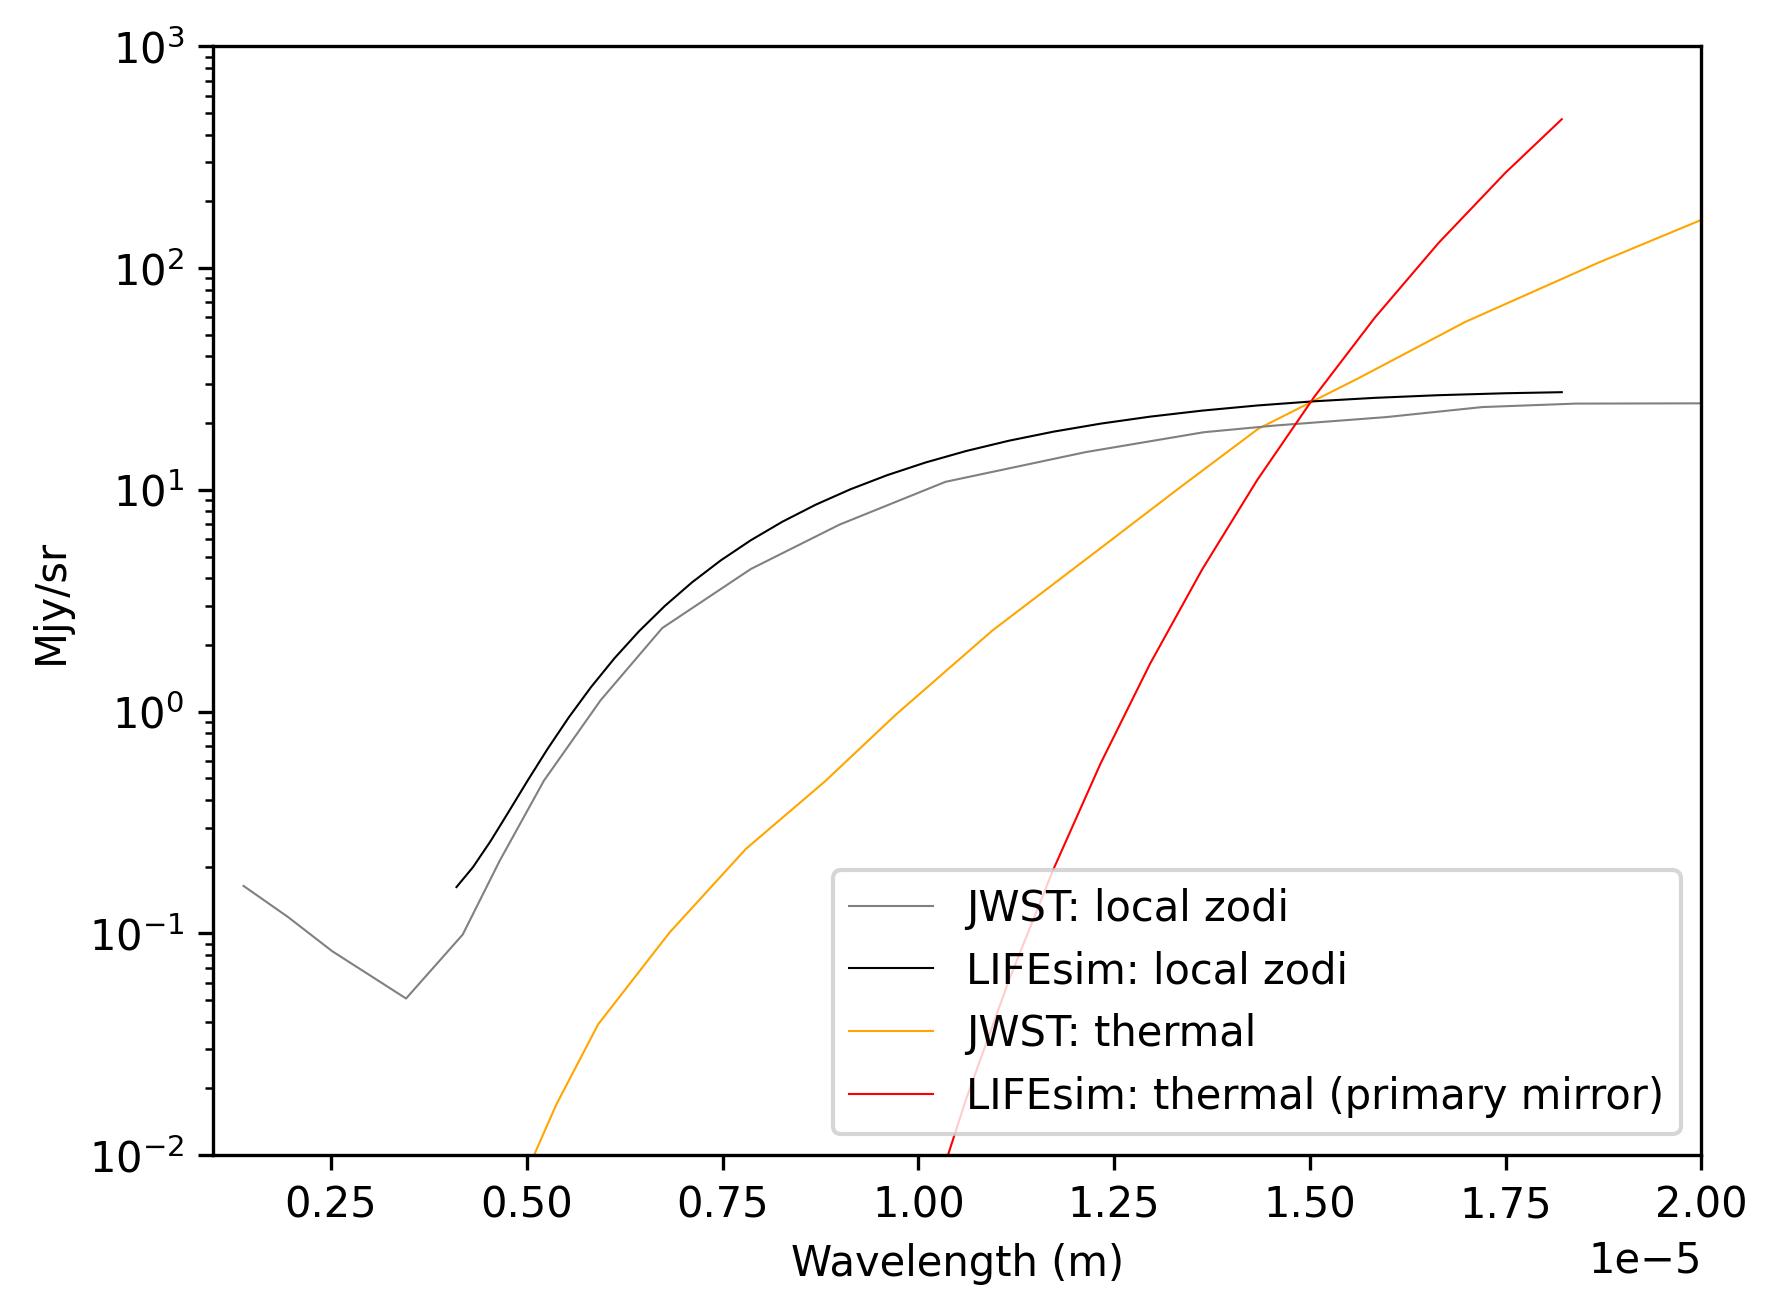

In [ ]:
# plot jwst reference
df1 = pd.read_csv("thermal_noise_testing/thermal_noise/jwst_ref_combined.txt", sep=",")
df1["x1"] = df1["x1"] * 1e-6
df1["x2"] = df1["x2"] * 1e-6    

fig, ax = plt.subplots(dpi=300)

jwst1 = ax.plot(df1["x1"], df1["y1"], lw=0.5, c='orange', label='JWST: thermal')
jwst2 = ax.plot(df1["x2"], df1["y2"], lw=0.5, c='gray', label='JWST: local zodi')

ln1 = ax.plot(spectrum_tmo[0], noise_star_local_mjy/omega, lw=0.5, c='black', label='LIFEsim: local zodi')
ln2 = ax.plot(spectrum_tmo[0], noise_thermal_mirror_mjy/omega, lw=0.5, c='red', label='LIFEsim: thermal (primary mirror)')

lns = jwst2 + ln1 + jwst1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Mjy/sr")
ax.set_ylim(1e-2, 1e3)
ax.set_xlim(1e-6, 20e-6)

plt.show()

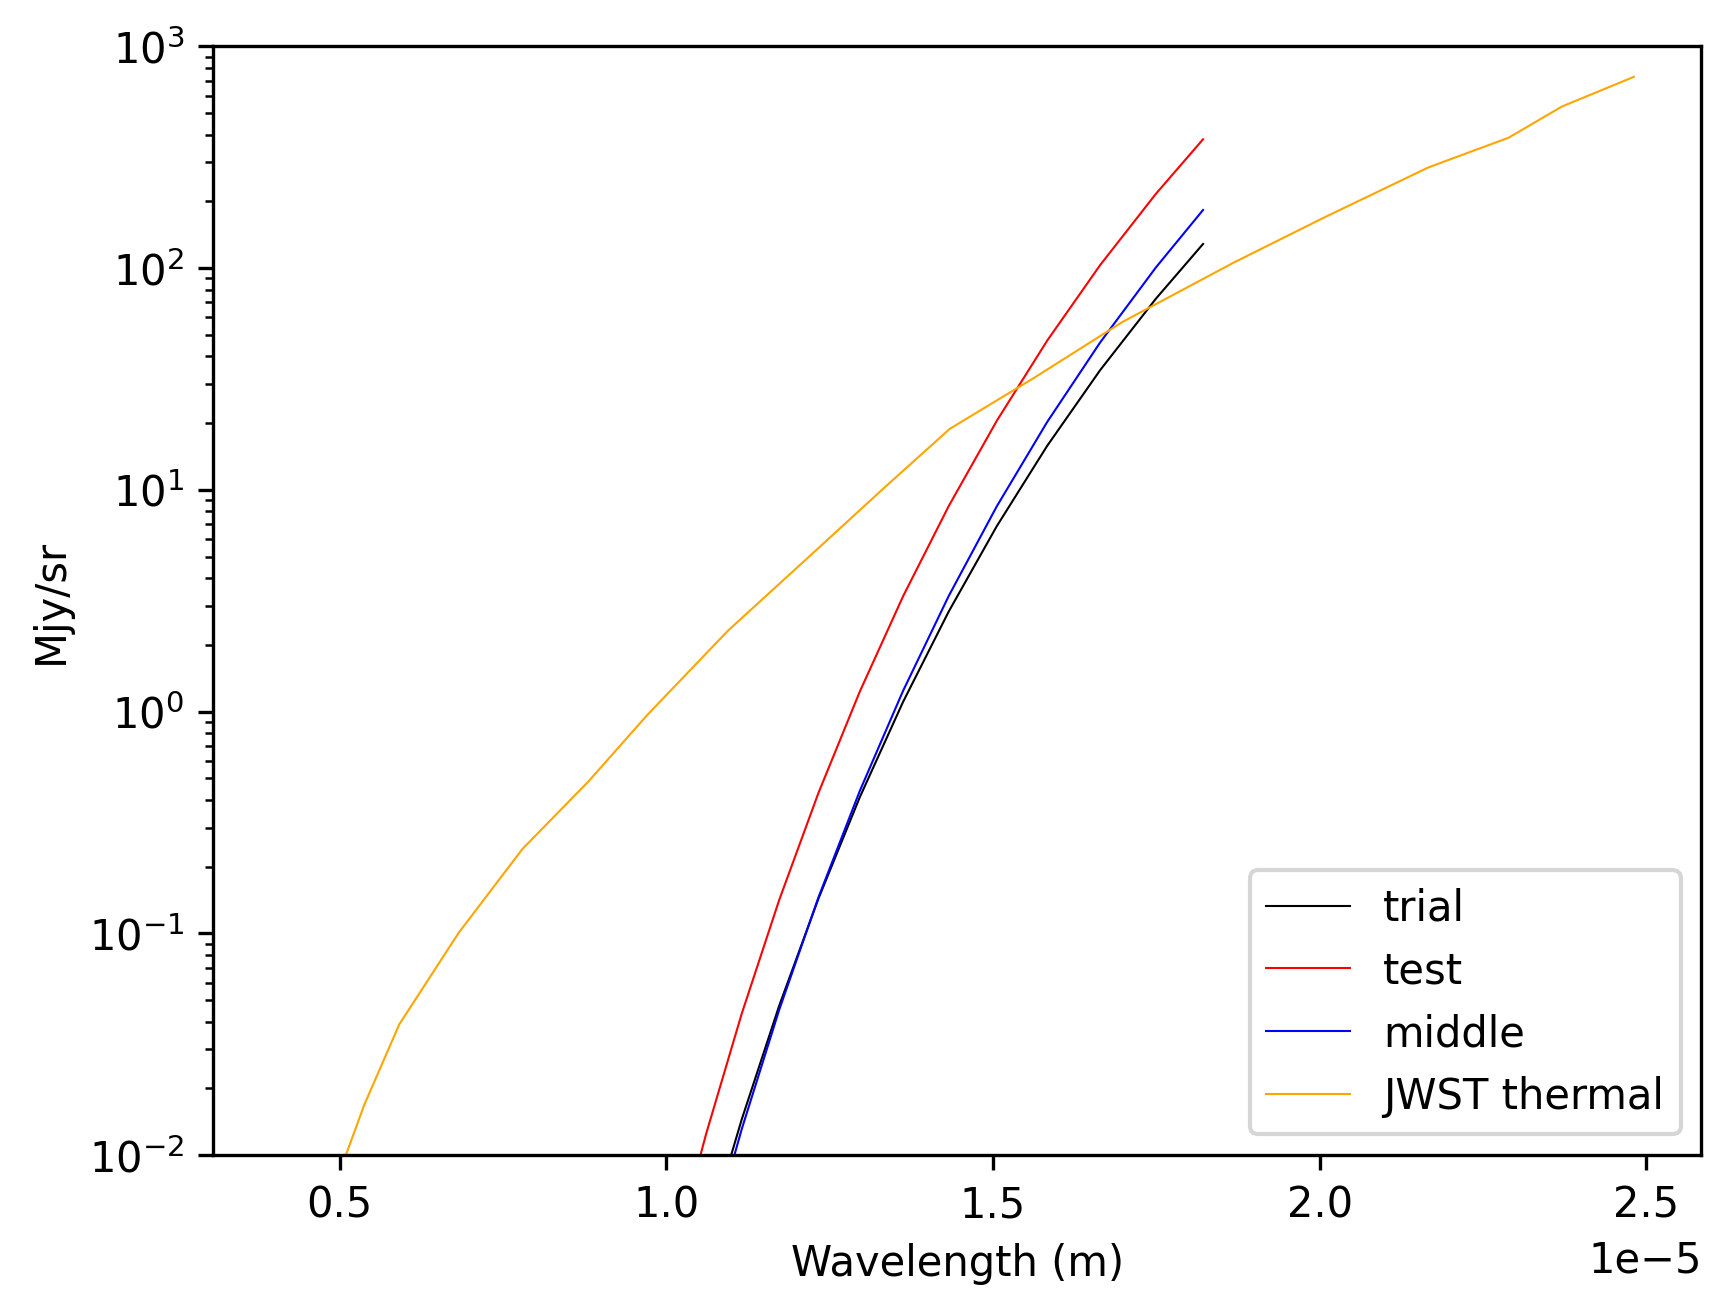

: 

: 

: 

In [ ]:
import lifesim.util.radiation as rad
trial = rad.black_body(mode='wavelength',
            bins=np.array(bus.data.inst['wl_bins']),
            width=np.array(bus.data.inst['wl_bin_widths']),
            temp=T_mirror) * np.pi * (bus.data.options.array['diameter'] / 2.) ** 2 /3 + \
        rad.black_body(mode='wavelength',
            bins=np.array(bus.data.inst['wl_bins']),
            width=np.array(bus.data.inst['wl_bin_widths']),
            temp=T_mirror-10) * np.pi * (bus.data.options.array['diameter'] / 2.) ** 2 /3 + \
        rad.black_body(mode='wavelength',
            bins=np.array(bus.data.inst['wl_bins']),
            width=np.array(bus.data.inst['wl_bin_widths']),
            temp=T_mirror-20) * np.pi * (bus.data.options.array['diameter'] / 2.) ** 2 /3

trial2 = trial * bus.data.options.array['m_emissivity'] * omega / u.sr / u.s
trial_mjy= photons_to_mjy(trial2, lam, dl, area, eff=bus.data.options.array['m_emissivity'])

middle = rad.black_body(mode='wavelength',
            bins=np.array(bus.data.inst['wl_bins']),
            width=np.array(bus.data.inst['wl_bin_widths']),
            temp=T_mirror-2) * np.pi * (bus.data.options.array['diameter'] / 2.) ** 2

middle2 = middle * bus.data.options.array['m_emissivity'] * omega / u.sr / u.s
middle_mjy= photons_to_mjy(middle2, lam, dl, area, eff=bus.data.options.array['m_emissivity'])

test = rad.black_body(mode='wavelength',
            bins=np.array(bus.data.inst['wl_bins']),
            width=np.array(bus.data.inst['wl_bin_widths']),
            temp=T_mirror) * np.pi * (bus.data.options.array['diameter'] / 2.) ** 2

test2 = test * bus.data.options.array['m_emissivity'] * omega / u.sr / u.s
test_mjy= photons_to_mjy(test2, lam, dl, area, eff=bus.data.options.array['m_emissivity'])

fig, ax = plt.subplots(dpi=300)

ln1 = ax.plot(spectrum_tmo[0], trial_mjy/omega, lw=0.5, c='black', label='trial')
ln2 = ax.plot(spectrum_tmo[0], test_mjy/omega, lw=0.5, c='red', label='test')
ln3 = ax.plot(spectrum_tmo[0], middle_mjy/omega, lw=0.5, c='blue', label='middle')
jwst1 = ax.plot(df1["x1"], df1["y1"], lw=0.5, c='orange', label='JWST thermal')

lns = ln1 + ln2 + ln3 + jwst1
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (m)')
ax.set_ylabel("Mjy/sr")
ax.set_ylim(1e-2, 1e3)

plt.show()


# snr comparison

In [88]:
min_temp = 30
max_temp = 31
temperatures = np.linspace(min_temp, max_temp, max_temp - min_temp + 1)
results = {}

for temp in temperatures:
    bus.data.options.set_scenario('baseline')
    bus.data.options.set_manual(dc_per_pix=temp)
    spectrum, flux_planet, noise = instrument.get_spectrum(
        temp_s=5778,
        radius_s=1,
        distance_s=10,
        lat_s=0.78,
        z=3,
        angsep=0.1,
        flux_planet_spectrum=[lam_lifesim, f_lifesim],
        safe_mode=True,
        integration_time=integration_time,
        baseline_to_planet=False
    )
    results[temp] = {
        'spectrum': spectrum,
        'flux_planet': flux_planet,
        'noise': noise
    }

In [89]:
wanted_temp = 30

In [90]:
noise_star = results[wanted_temp]['noise'][1]
noise_star_local = noise_star[0]
noise_star_starleak = noise_star[1]

noise_universe = results[wanted_temp]['noise'][2][0]

noise_thermal = results[wanted_temp]['noise'][3] 
noise_thermal_mirror = noise_thermal[0]
noise_thermal_detector = noise_thermal[2]
noise_thermal_inst = noise_thermal[1]

noise_dc_electron = results[wanted_temp]['noise'][4][0]
noise_dc_photon = noise_dc_electron/0.7

spectrum = results[wanted_temp]['spectrum']

noise_planet = results[wanted_temp]['noise'][0]/integration_time/bus.data.inst['eff_tot']/bus.data.options.array['num_outputs'] - noise_star_local - noise_star_starleak - noise_universe - noise_thermal_mirror - noise_thermal_detector - noise_dc_photon

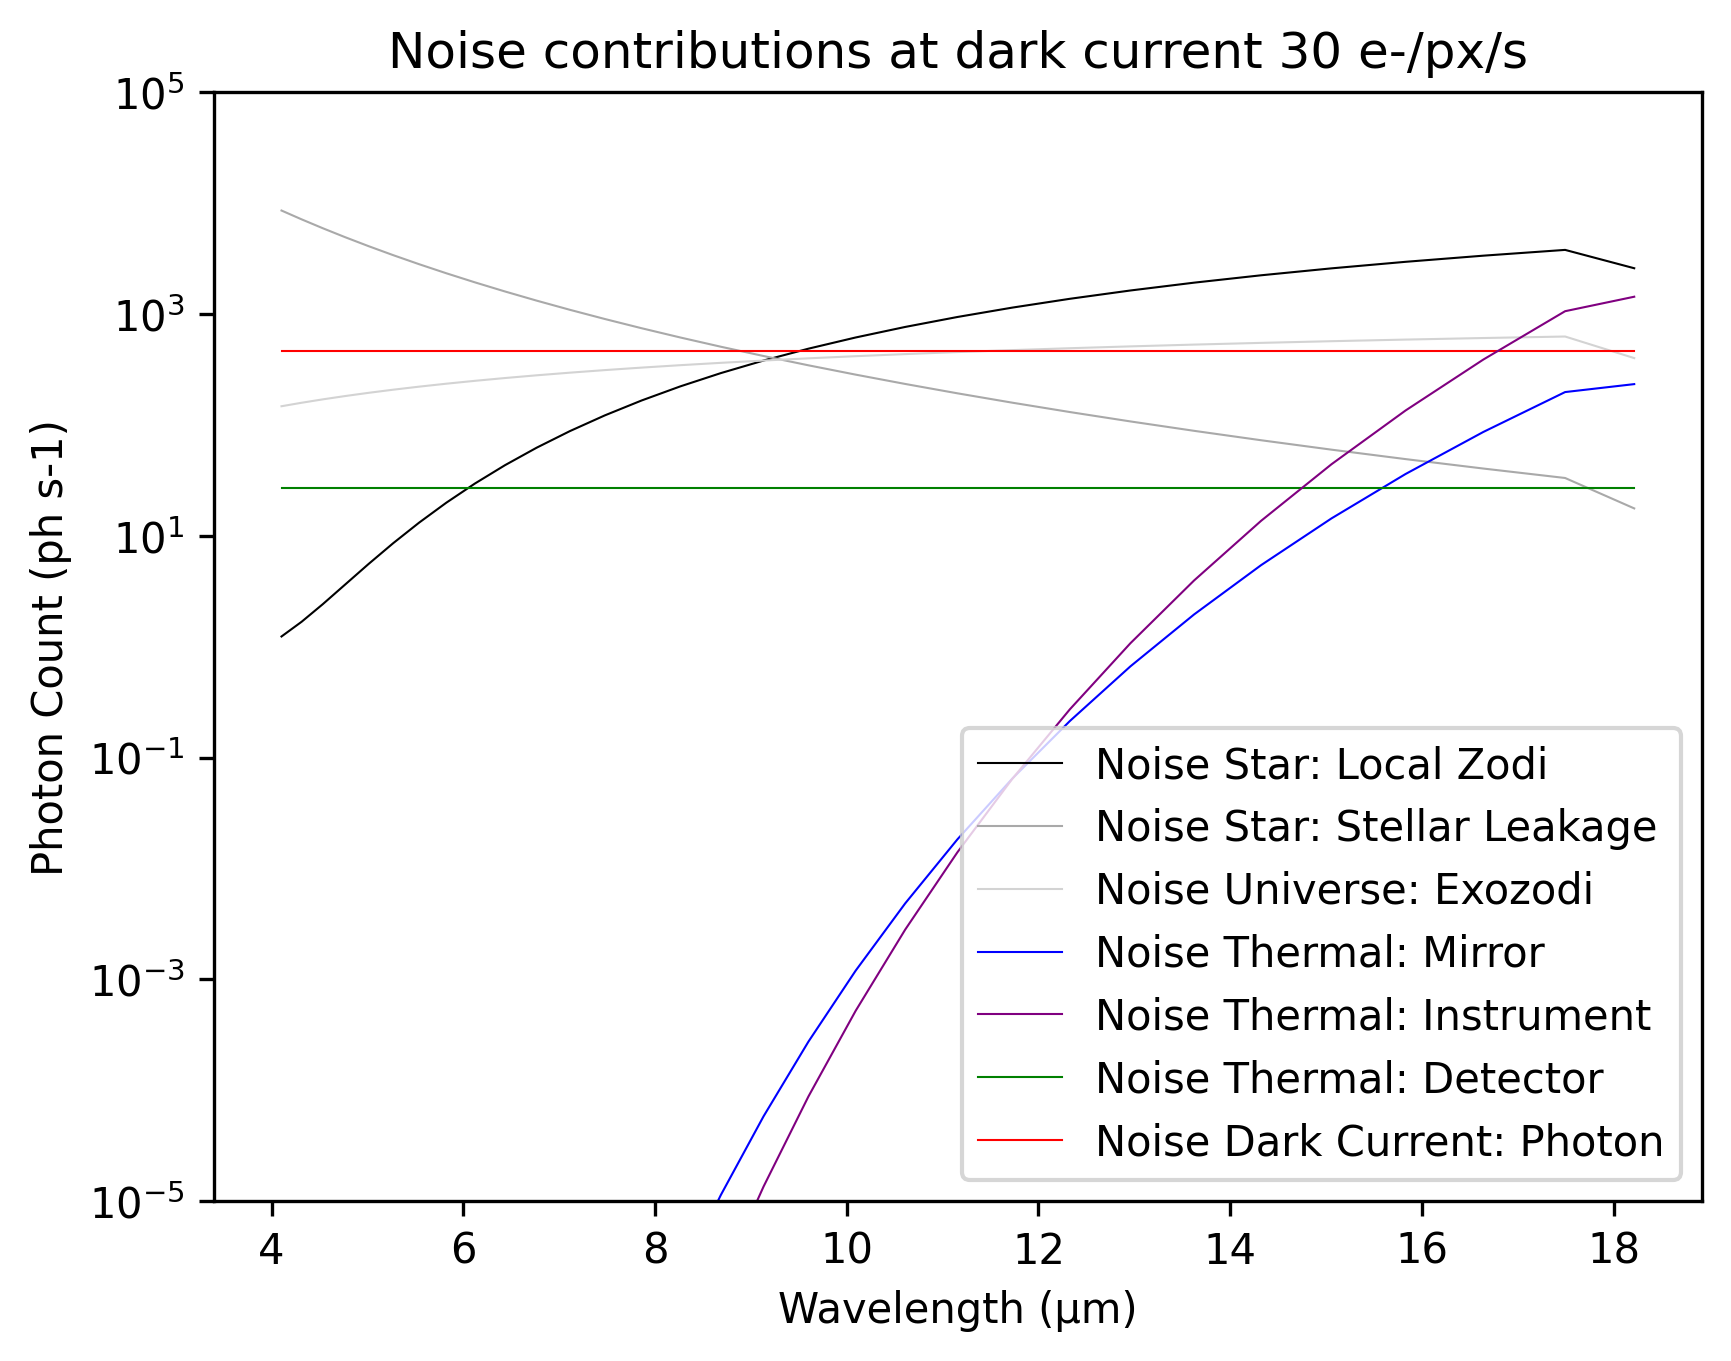

In [91]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(spectrum_tmo[0], noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(spectrum_tmo[0], noise_planet, lw=0.5, c='gray', label='Noise Planet')

x = spectrum[0] * 1e6

ln1 = plt.plot(x, noise_star_local, lw=0.5, c='black', label='Noise Star: Local Zodi')
ln2 = plt.plot(x, noise_star_starleak, lw=0.5, c='darkgray', label='Noise Star: Stellar Leakage')
ln3 = plt.plot(x, noise_universe, lw=0.5, c='lightgray', label='Noise Universe: Exozodi')

ln4 = plt.plot(x, noise_thermal_mirror, lw=0.5, c='blue', label='Noise Thermal: Mirror')
ln5 = plt.plot(x, noise_thermal_detector, lw=0.5, c='green', label='Noise Thermal: Detector')
ln6 = plt.plot(x, noise_dc_photon, lw=0.5, c='red', label='Noise Dark Current: Photon')
ln7 = plt.plot(x, noise_thermal_inst, lw=0.5, c='purple', label='Noise Thermal: Instrument')

lns = ln1 + ln2 + ln3 + ln4 + ln7 + ln5 + ln6 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e-5, 1e5)
ax.set_title(f"Noise contributions at dark current {wanted_temp} e-/px/s")

plt.show()

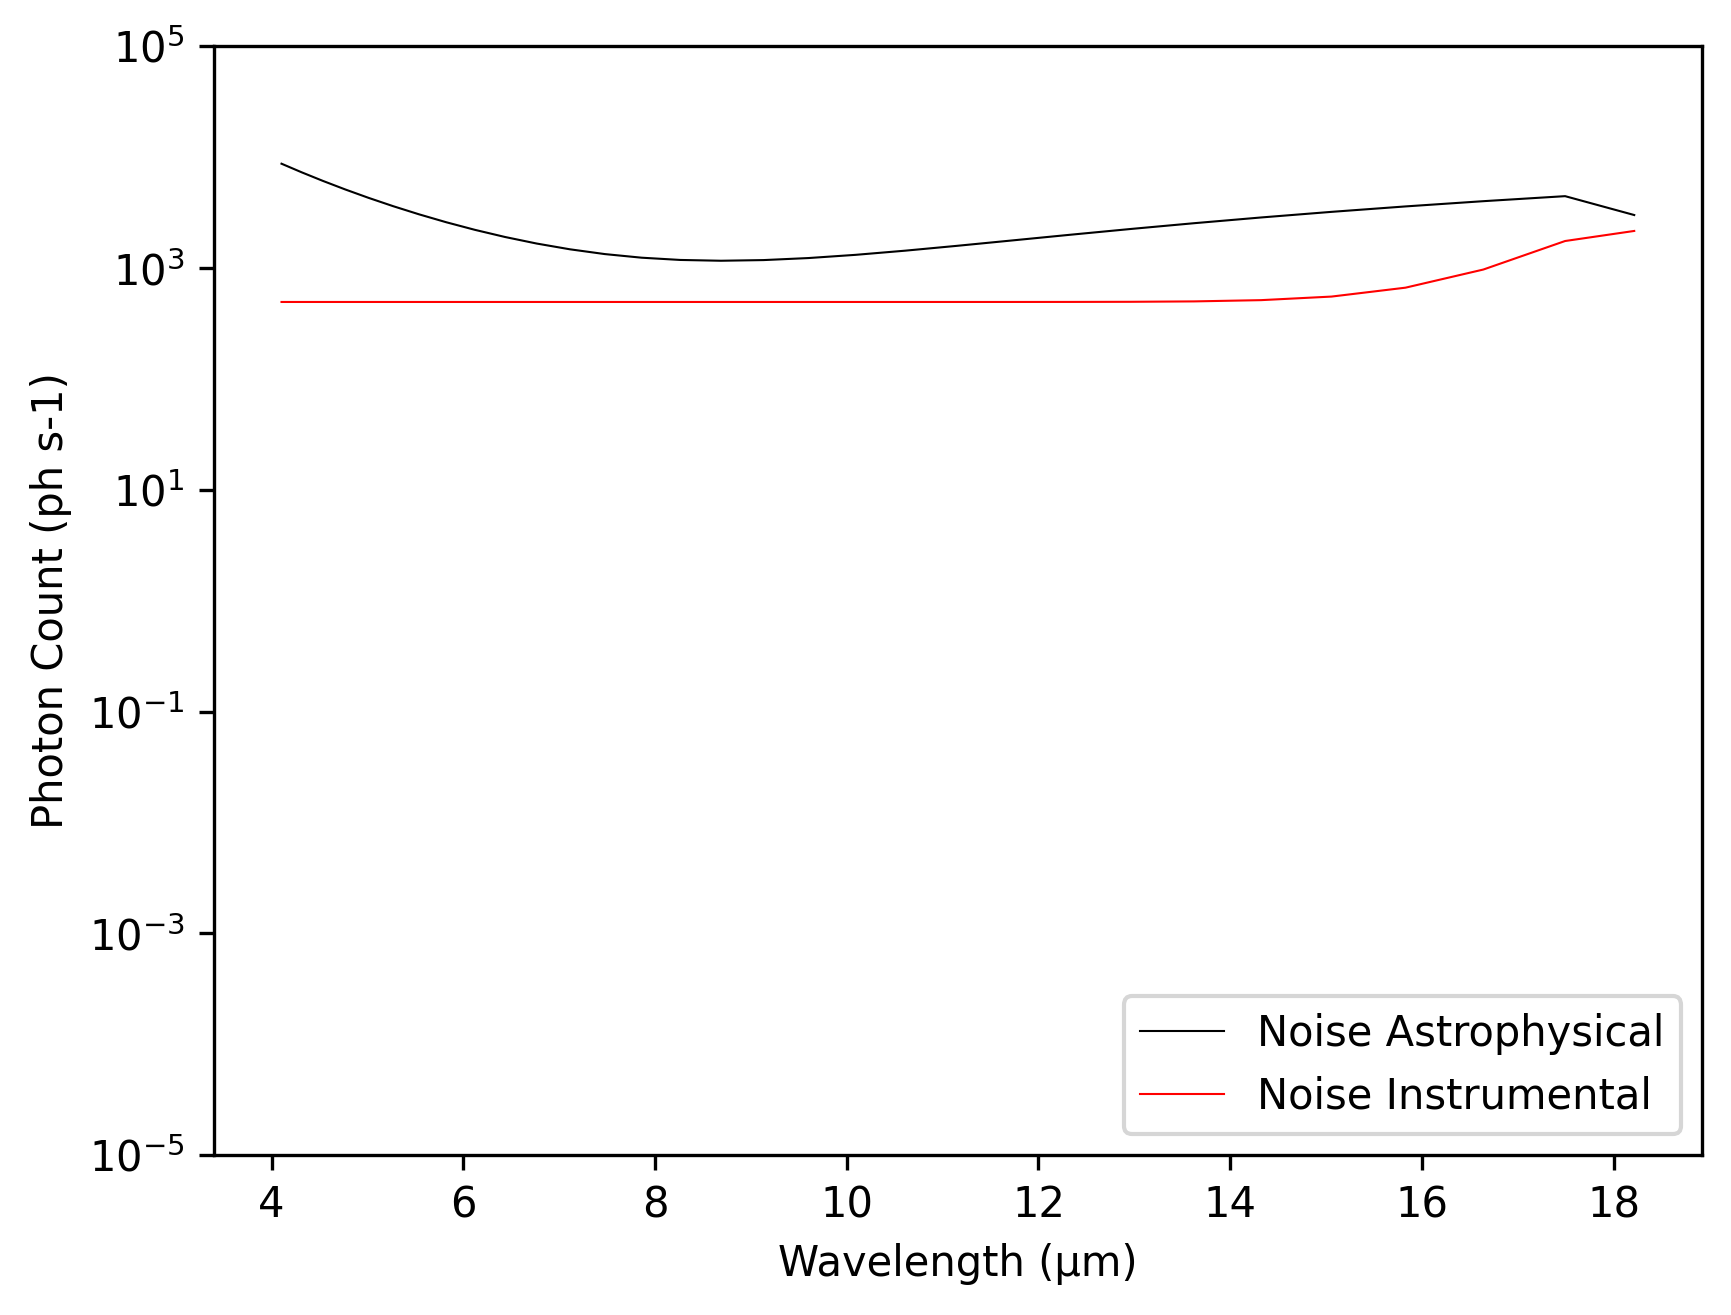

In [93]:
fig, ax = plt.subplots(dpi=300)

# lntot = plt.plot(x, noise_tmo[0], lw=0.5, c='black', label='Total Noise')
# lnplanet = plt.plot(x, noise_planet, lw=0.5, c='gray', label='Noise Planet')

noise_astrophysical = noise_star_local + noise_star_starleak + noise_universe
noise_instrumental = noise_thermal_mirror + noise_thermal_detector + noise_dc_photon + noise_thermal_inst

ln1 = plt.plot(x, noise_astrophysical, lw=0.5, c='black', label='Noise Astrophysical')
ln2 = plt.plot(x, noise_instrumental, lw=0.5, c='red', label='Noise Instrumental')

lns = ln1 + ln2 # + lntot + lnplanet
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='lower right')

ax.set_yscale('log')
ax.set_xlabel('Wavelength (µm)')
ax.set_ylabel("Photon Count (ph s-1)")
ax.set_ylim(1e-5, 1e5)

plt.show()